# TMA4215 Numerical Mathematics – Project part 1: Approximation of functions

**Contents**
- [0. Setup](#setup)
- [1a) Lagrange interpolation: equidistant vs. Chebyshev nodes](#task-a)
- [1b) Convergence and error bounds](#task-b)
- [1c) Piecewise polynomial interpolation](#task-c)
- [1d) Radial basis function (RBF) interpolation](#task-d)
- [1e) Optimal node distribution with gradient descent](#task-e)
- [1f) Optimal nodes for polynomial interpolation](#task-f)
- [Statement on the use of AI tools](#ai-statement)

## <a id="setup" name="setup"></a>0. Setup

In [1]:
# Imports and global settings used by all tasks
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy.special import factorial
from IPython.display import display

# Use double precision (float64) for all PyTorch tensors
torch.set_default_dtype(torch.float64)
assert torch.get_default_dtype() == torch.float64

plt.style.use("bmh")

## <a id="task-a" name="task-a"></a>1a) Lagrange interpolation: equidistant vs. Chebyshev nodes

### Implementation

In [2]:
# functions to interpolate, define and name them for plotting and ease of use
def runge(x):
    """f(x) = 1 / (1 + x^2)."""
    return 1.0 / (1.0 + x**2)
runge.__name__ = "Runge function"

def f_cos(x):
    """f(x) = cos(2*pi*x)"""
    return np.cos(2 * np.pi * x)
f_cos.__name__ = "cos(2*pi*x)"

def f_expsin(x):
    """f(x) = exp(3x) * sin(2x)"""
    return np.exp(3 * x) * np.sin(2 * x)
f_expsin.__name__ = "exp(3x) * sin(2x)"

In [3]:
# nodes generation functions
def equidistant_nodes(a, b, n):
    """
    Generate n+1 equidistant nodes on [a, b].

    parameters:
    a (float): left endpoint of the interval
    b (float): right endpoint of the interval
    n (int): number of intervals

    returns:
    np.ndarray: array of n+1 equidistant nodes
    """
    return np.linspace(a, b, n + 1)


def chebyshev_nodes(a, b, n):
    """
    Generate n+1 Chebyshev nodes on [a, b].

    parameters:
    a (float): left endpoint of the interval
    b (float): right endpoint of the interval
    n (int): number of intervals

    returns:
    np.ndarray: array of n+1 Chebyshev nodes
    """
    k = np.arange(n + 1)
    #t = np.cos(k * np.pi / n)[::-1]   # Used the wrong formula for Chebyshev nodes, changed to the correct one below
    t = np.cos((k + 0.5) * np.pi / (n + 1))[::-1]   # Chebyshev nodes on [-1, 1]
    return 0.5 * (b - a) * t + 0.5 * (b + a)         # Chebyshev nodes on [a, b]



def get_nodes(nodes, a, b, n):
    """
    Get the nodes for interpolation. Important since we want to be able to switch between equidistant and Chebyshev nodes easily.

    parameters:
    nodes (str): type of nodes to generate ("equidistant" or "chebyshev")
    a (float): left endpoint of the interval
    b (float): right endpoint of the interval
    n (int): number of intervals

    returns:
    np.ndarray: array of n+1 nodes
    """
    if nodes == "equidistant":
        return equidistant_nodes(a, b, n)
    elif nodes == "chebyshev":
        return chebyshev_nodes(a, b, n)
    raise ValueError("nodes must be 'equidistant' or 'chebyshev'")

In [4]:
def lagrange_eval(x_nodes, y_nodes, x_eval):
    """
    Evaluate the Lagrange interpolating polynomial at given points.

    Parameters
    x_nodes (ndarray): The x-coordinates of the interpolation nodes.
    y_nodes (ndarray): The y-coordinates of the interpolation nodes.
    x_eval (ndarray): The x-coordinates at which to evaluate the interpolating polynomial.

    Returns
    ndarray: The y-coordinates of the interpolating polynomial at the evaluation points.
    """
    # Convert inputs to numpy arrays for consistency
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x = np.asarray(x_eval, dtype=float)

    
    result = np.zeros(x.shape, dtype=float) #initialize result array with zeros of the same shape as x
    for i in range(x_nodes.size): # loop over each node to compute the Lagrange basis polynomial
        basis = np.ones(x.shape, dtype=float)      # create a vector that we can add the parts of the lagrenge polynomial to
        for j in range(x_nodes.size):
            if j != i:
                basis *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += y_nodes[i] * basis


    # If the result is a scalar (0-dimensional), return it as a float. Otherwise, return the result as an array.
    return float(result) if result.ndim == 0 else result


def make_lagrange(f, a, b, n, nodes="equidistant",noise = 0):
    """
    Create a Lagrange interpolating function for a given function f on the interval [a, b] using n intervals and specified node type.
    This is used to create a callable function that can be evaluated at any point in the interval [a, b]. 
    Makes implementing  later functions easier since we can just call this function to get the interpolating function.
    Also gives the function some attributes that allows us to not need to keep track of the nodes and function separately, since we can just access them from the function itself.


    parameters:
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    n (int): The number of intervals.
    nodes (str): The type of nodes to use ("equidistant" or "chebyshev").
    noise (float): The standard deviation of Gaussian noise to add to the evaluation points.

    returns:
    callable: The Lagrange interpolating function.
    """

    # Get the nodes and evaluate the function at those nodes
    x_nodes = get_nodes(nodes, a, b, n)
    y_nodes = np.asarray(f(x_nodes), dtype=float)

    # Add noise to the evaluation points if specified. Mainly used in 1c for stability tests.
    # Noise is added as a percentage of the function value at the node, so that the noise is relative to the function value.
    if noise > 0:
        y_nodes += np.random.normal(0, noise, size=y_nodes.shape)*y_nodes

    # Create the Lagrange interpolating function
    def g(x):
        return lagrange_eval(x_nodes, y_nodes, x)

    # Add attributes to the function for easy access to the nodes, function, and interval
    g.nodes = x_nodes
    g.label = f"n = {n} ({nodes})"
    g.function = f
    g.interval = (a, b)   
    return g

In [5]:
def plot_interpolant(a, b, *interps, n_plot=1000):
    """
    Plot the original function and its interpolants.

    Parameters:
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    *interps: The interpolant functions to plot.
    n_plot (int): The number of points to use for plotting.

    returns:
    None
    """
    f = interps[0].function   
    x = np.linspace(a, b, n_plot)

    plt.figure(figsize=(10, 6))
    plt.plot(x, f(x), color="black", linestyle="dashed", label="f(x)")
    for i, g in enumerate(interps):
        plt.plot(x, g(x), color=f"C{i}", label=g.label)
        plt.scatter(g.nodes, f(g.nodes), color=f"C{i}", s=25, zorder=3)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Interpolation of {f.__name__} on [{a}, {b}]")
    plt.legend()
    plt.grid(True)
    plt.show()

### Runge function on [-5, 5] with n = 10

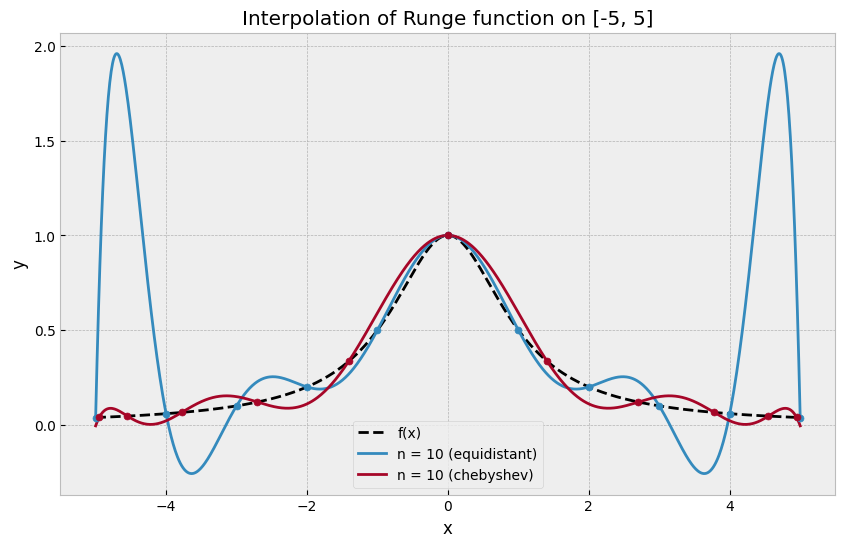

In [6]:
def taska_1():
    a= -5
    b = 5
    interpolant1 = make_lagrange(runge, a, b, 10)
    interpolant2 = make_lagrange(runge, a, b, 10,'chebyshev')
    plot_interpolant(a, b, interpolant1, interpolant2)

taska_1()


### Prediction and results for n = 15, 20, 30

We now want to increase the ampount of nodes we interpolate over. From [bok side 186] we know that with an increasing number of nodes the max error will increase. Usually called the *"Runge Phenomenon"*. This can be explained by noticing that the Taylor approximation around 0 of the `Runge` function will converge on the unit disc with radius 1, but not outside due to the poles at $\pm i$. We know that the chebyshev nodes are supposed to give a better approximation, so we expect them to blow up, but less than with `equidistant` nodes.

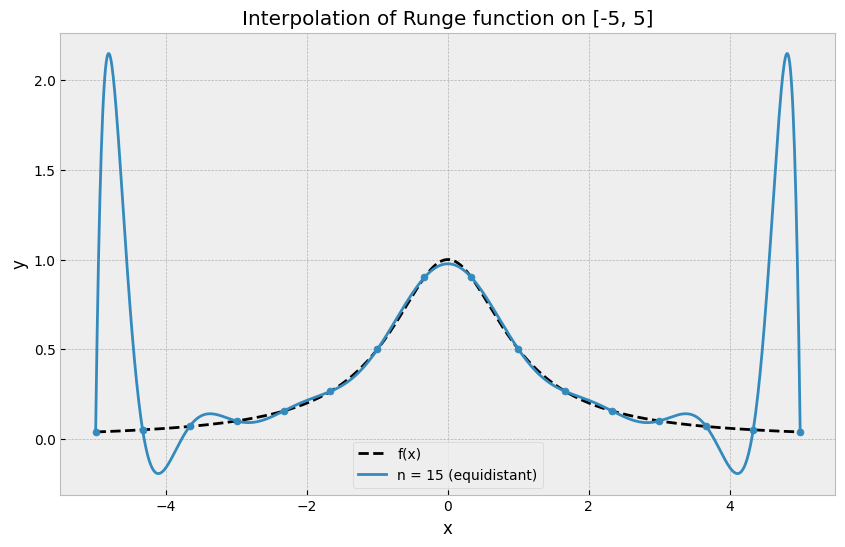

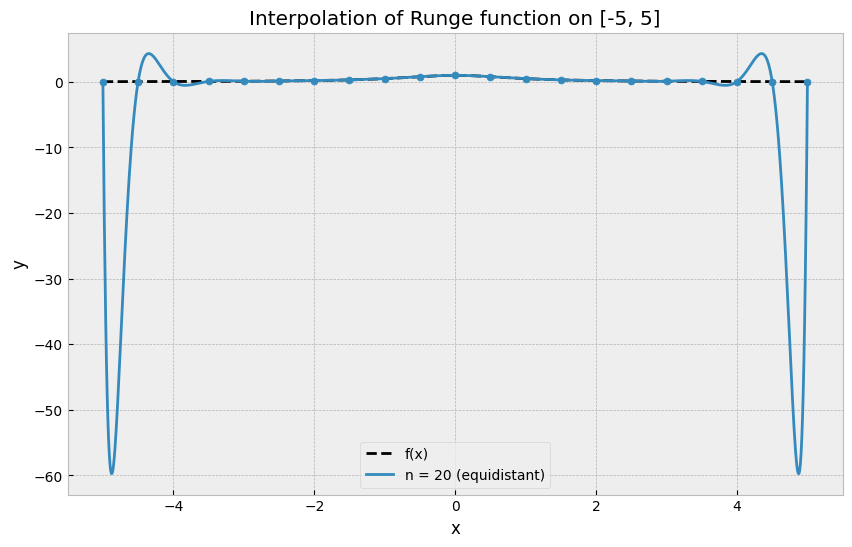

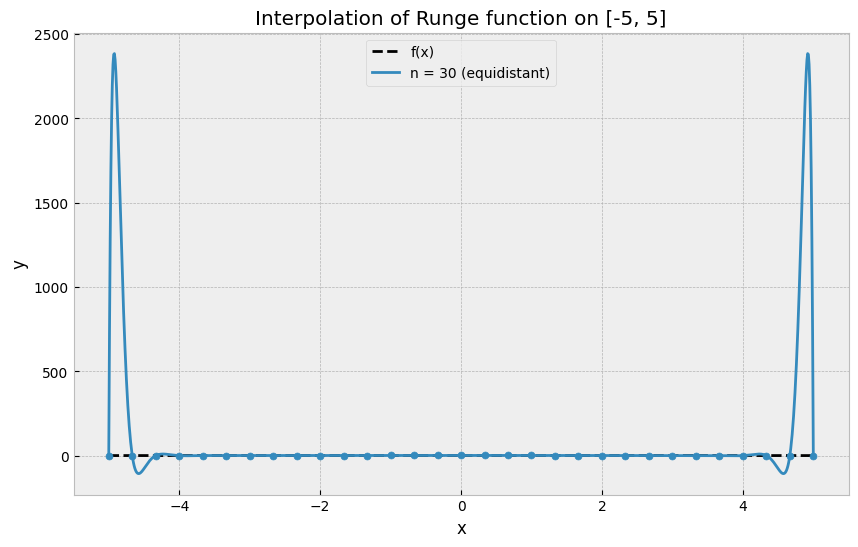

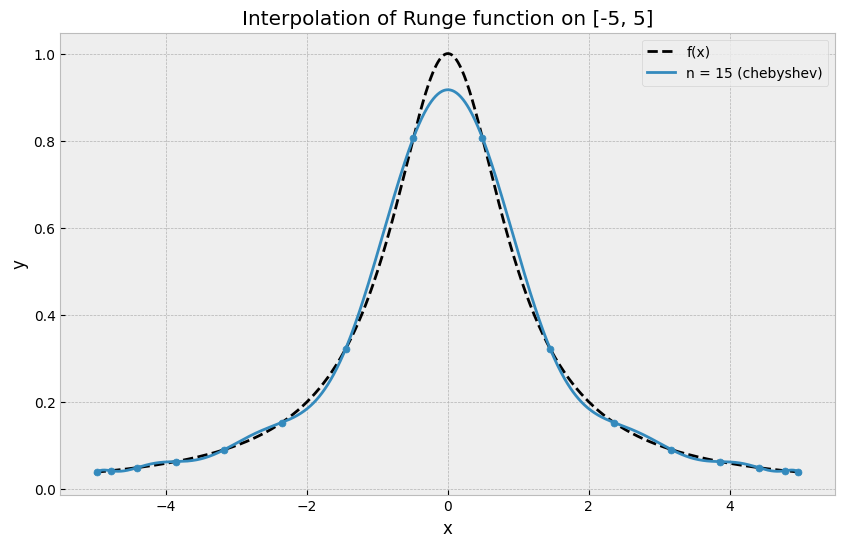

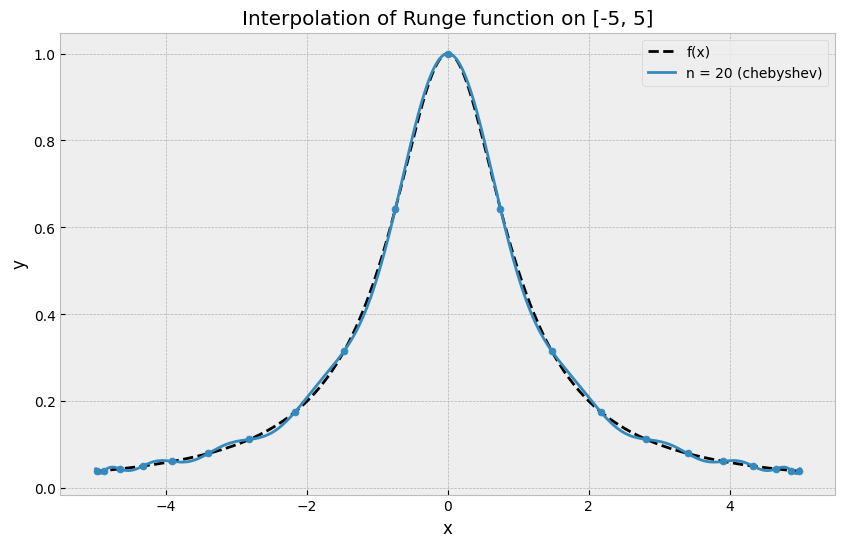

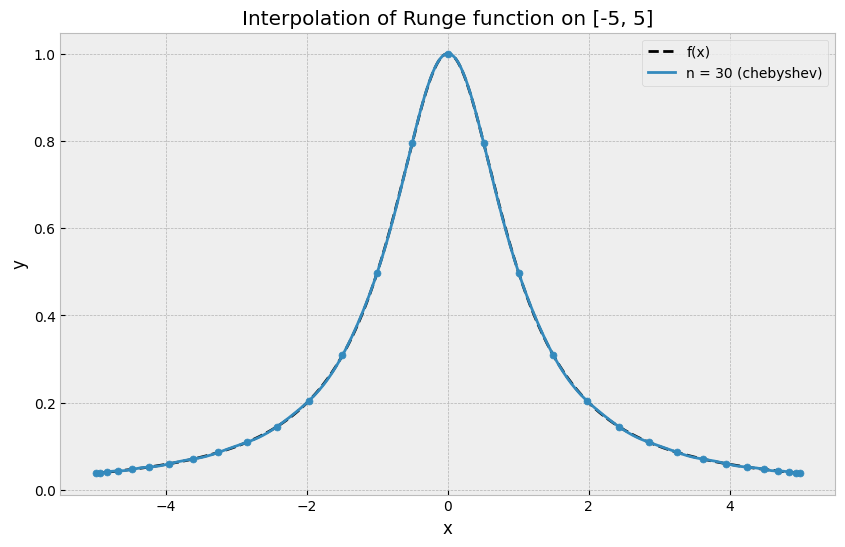

In [7]:
def taska_2():
    a= -5
    b = 5
    interpolants_equidistant = []
    interpolants_chebyshev = []
    for n in [15, 20,30]:
        interpolants_equidistant.append(make_lagrange(runge, a, b, n))
        interpolants_chebyshev.append(make_lagrange(runge, a, b, n,'chebyshev'))

    for interpolant in interpolants_equidistant:
        plot_interpolant(a, b, interpolant)

    for interpolant in interpolants_chebyshev:
        plot_interpolant(a, b, interpolant)
taska_2()

As expected the interpolant blows up for larger of values of N when equidistant nodes are used. While the chebyshev nodes actually converge to the Runge function. This is surprising compared to what we know of the Runge function from class. We know that the `Chebyshev` nodes are the interpolation nodes that give the best approximation with respect to the $\infty$-norm, but there must be something inherently special about the Chebyshev nodes that surpress the blow up of the interpolation.

### Runge function on [-1, 1]

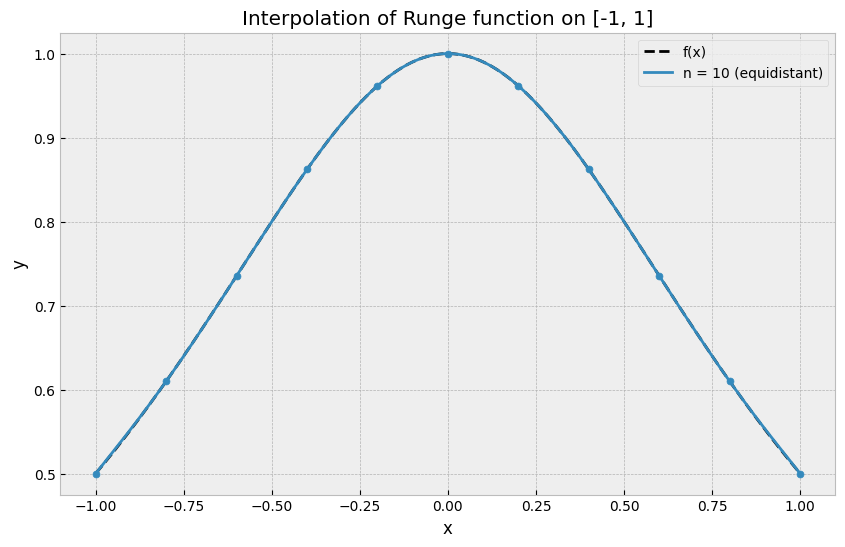

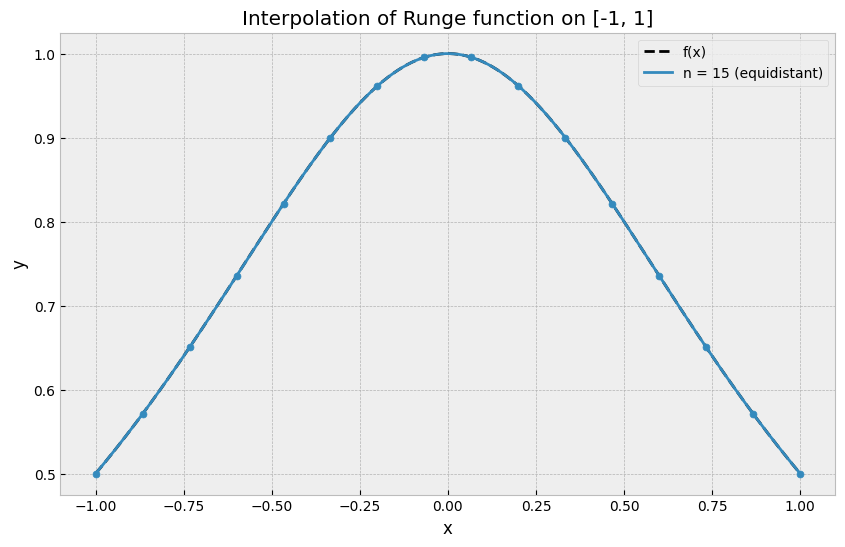

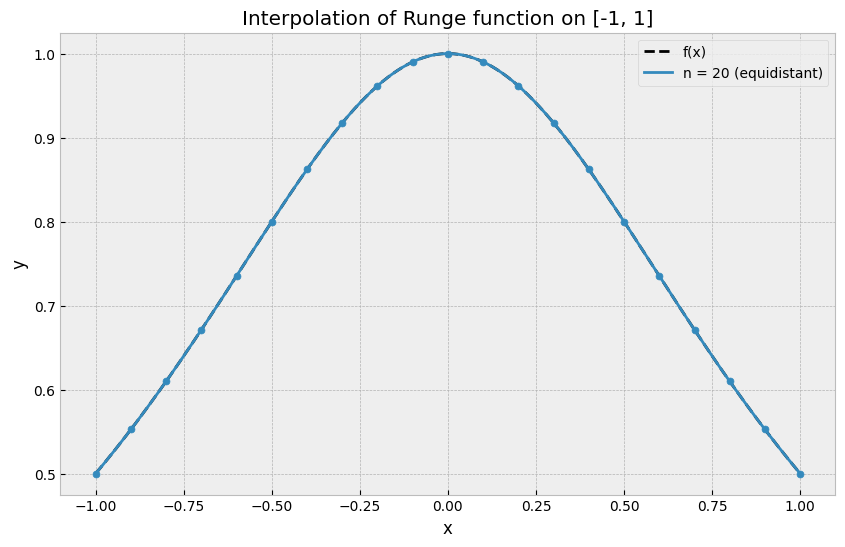

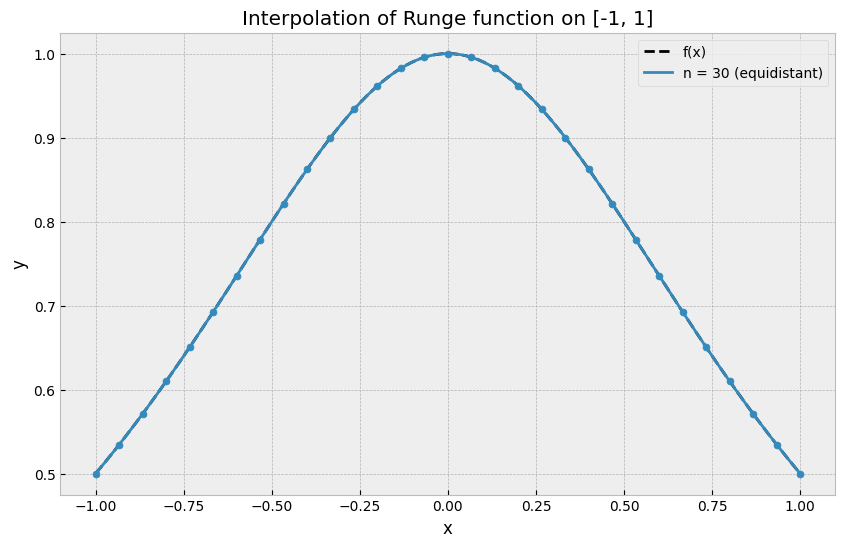

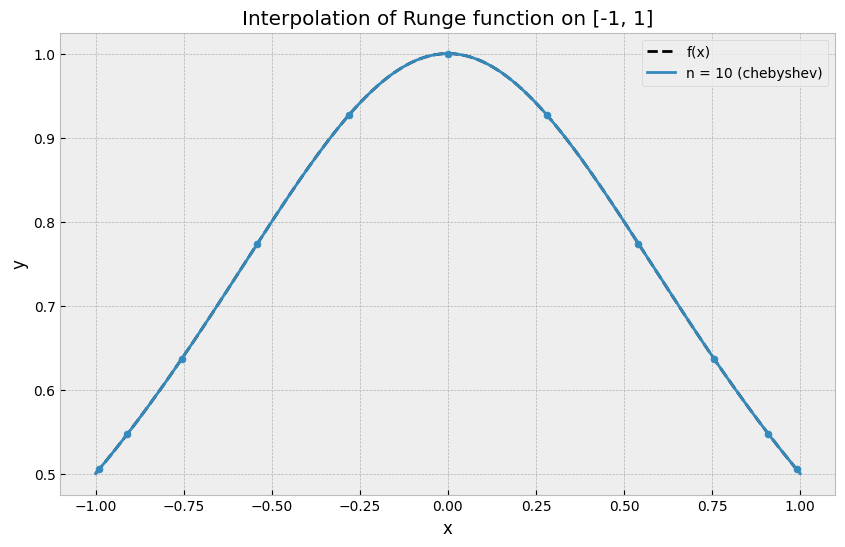

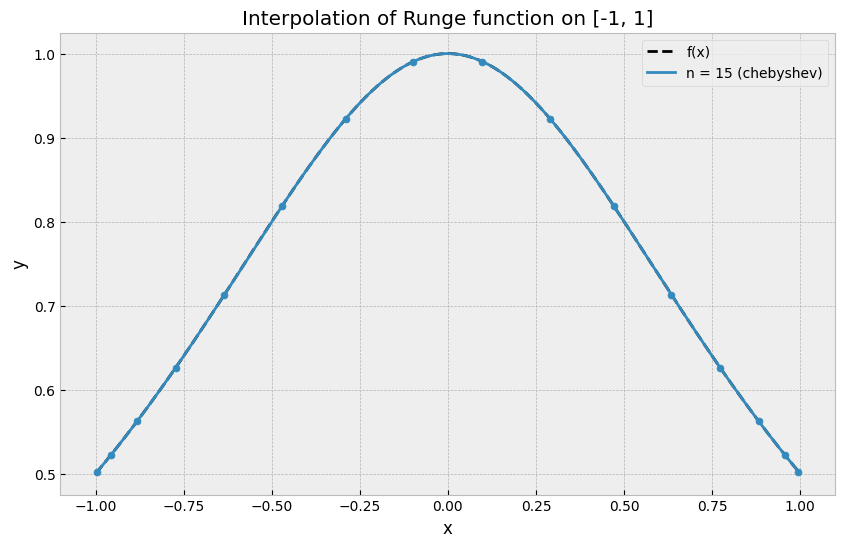

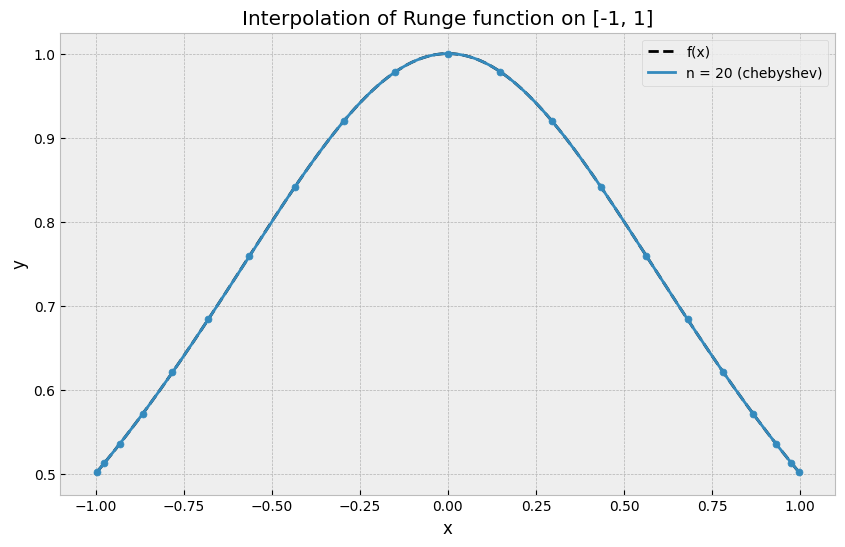

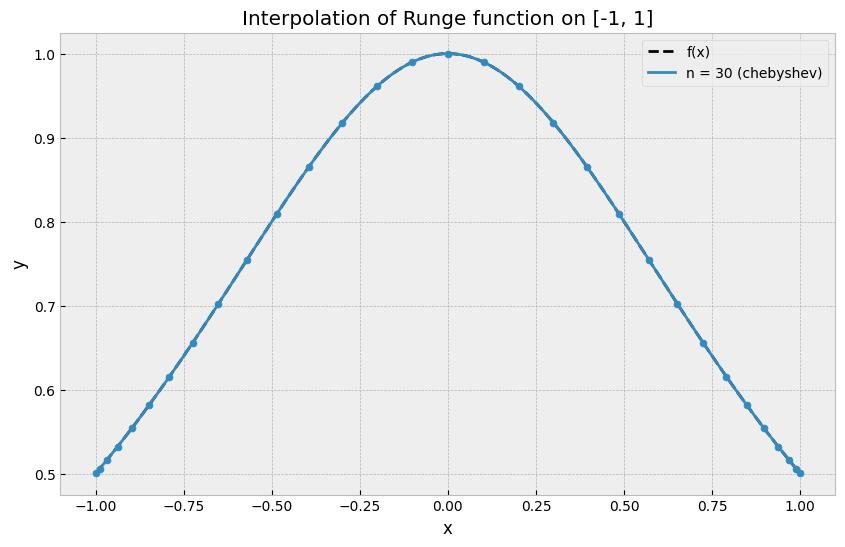

In [8]:
def taska_3():
    a = -1
    b = 1

    interpolants_equidistant = []
    interpolants_chebyshev = []
    for n in [10,15,20,30]:
        interpolants_equidistant.append(make_lagrange(runge, a, b, n))
        interpolants_chebyshev.append(make_lagrange(runge, a, b, n, 'chebyshev'))

    for interpolant in interpolants_equidistant:
        plot_interpolant(a, b, interpolant)

    for interpolant in interpolants_chebyshev:
        plot_interpolant(a, b, interpolant)

taska_3()

We have now shortened the interval that we interpolate the Runge function over. Now the interpolation seems to converge for both `equidisant` and `Chebyshev` nodes. Note that the plots do not give sufficient evidence that this is a trend that will go on forever, but we atleast see a significant change from the interpolation over $[-5,5]$. One can guess that this is due to the the poles of the `Runge` being further from the origo than the area we interpolate over, but it is most likely outside the scope of this project.

## <a id="task-b" name="task-b"></a>1b) Convergence and error bounds

### Why the interpolation converges

We now want to look deeper into interpolation of functions. In addition to the `Runge` function we look at the following functions.
1. $$f_1(x) = \cos(2\pi x), \qquad x \in [0, 1]$$
2. $$f_2(x) = e^{3x}\sin(2x), \qquad x \in \left[0, \frac{\pi}{4}\right]$$

We will mainly look at $\lVert \cdot \lVert_{\infty}$. Since we are over a measureably finite area we can utilise:
$$||f||_p \leq (\mu([a,b]))^{1/p} ||f||_{\infty}$$
Where $\mu$ is the measure we use for integration. In our case we use the Lebesque measure. Therefore convergence in $||\cdot||_{\infty}$ is sufficient for convergence in $||\cdot||_2$ over $[a,b]$.

For a given set of nodes $X$ of size $n+1$ over $[a,b]$, and the uniqe polynomial $p_n$ that interpolates a function $f \in C^{n+1}[a,b]$, we know $\exists \xi = \xi (x) \text{s.t.}:$

$$f(x) - p_n(x) = \dfrac{f^{(n+1)}(\xi)}{(n+1)!} \pi_{n+1}(x)$$
where $$\pi_{n+1}(x) = (x-x_0)...(x-x_n)$$

We start with $f_1(x) = \cos(2\pi x)$. It is trivial to see: 
$$f_1^{(n+1)}(x) = (2\pi)^{n+1}\cos\!\left(2\pi x + \frac{(n+1)\pi}{2}\right)$$

From this we get the expression $M_{1,n+1} \leq (2\pi)^{n+1}$. Where $M_{1,n+1}$ is the maximum of the $(n+1)\text{-th}$ derivative over interval we interpolate over. 

The derivative of $f_2$ is less straightforward. For real $x$ we can write $f_2(x) = e^{3x}\sin(2x) = \operatorname{Im}\big(e^{(3+2i)x}\big)$, and since $\operatorname{Im}$ is real-linear, differentiation with respect to $x$ commutes with it. Writing $3+2i = \sqrt{13}\,e^{i\theta}$ with $\theta = \arctan(2/3)$, we get
$$
f_2^{(n+1)}(x)
= \operatorname{Im}\big((3+2i)^{n+1} e^{(3+2i)x}\big)
= 13^{\frac{n+1}{2}}\, e^{3x} \sin\big((n+1)\theta + 2x\big).
$$
Using $|\sin(\cdot)| \le 1$ and that $e^{3x}$ is increasing on $\left[0, \frac{\pi}{4}\right]$, we obtain
$$
M_{2,n+1} \leq 13^{\frac{n+1}{2}}\, e^{3\pi/4}.
$$
This means that both functions are in $C^{n+1}[a,b]$, and therefore we can use the theorem above.

Neither $M_1^{n+1}$ nor $M_2^{n+1} $ grows faster than $(n+1)!$ Therefore we only need to look at the $||\pi_{n+1}||_{\infty}$. Note that for our functions $b-a \leq 1$ 

For `Chebyshev` nodes we know from Theorem 8.7 in [BOK] that $||\pi_{n+1}||_{\infty} \leq (b-a)^{n+1}\cdot 2^{-2n-1} \leq 2^{-2n-1} \rightarrow 0 $. 

For `Equidistant` nodest the convergence is slightly harder. For equidistant nodes we can write $x_i = a + ih$ and $x = a + sh$ where $s \in [0,n]$. That allows us to write:
$$
\left|\pi_{n+1}(x)\right|
= h^{n+1}\prod_{i=0}^{n}\left|(s-i)\right|
$$

We know that the last product will be maximal for $s \in [0,1]$. Noticing that $s(s-1)\leq 1/4$ and $ \prod_{i=2}^{n}\left|(s-i)\right| \leq \prod_{i=2}^{n}\left|(i)\right| = n!$ for $s \in [0,1]$ We get:

$$
||\pi_{n+1}(x)||_{\infty}
\leq h^{n+1} \cdot n! /4
= \dfrac{(b-a)^{n+1} n!}{4n^{n+1}}
\leq \dfrac{n!}{4n^{n+1}}
\rightarrow 0
$$
Where the last part can be verified by Stirlings formula.

Therefore we conclude that our interpolations will theoreically converge in both norms for both node types.

### Implementation

In [9]:
def error(g):
    """
    Compute the maximum and L2 error of the interpolant g compared to the original function f.

    Parameters
    g (callable): The interpolant function.

    Returns:
    tuple: A tuple containing the maximum error and the L2 error.
    """

    # get the original function
    f = g.function   

    # create a fine grid of points to evaluate the error
    N = len(g.nodes) * 100
    a, b = g.interval
    x = np.linspace(a, b, N)

    # compute an array of absolute errors between the original function and the interpolant
    error = np.abs(f(x) - g(x))

    #approximate the maximum error and the L2 error 
    return (np.max(error), np.sqrt(np.sum(error**2) *(b - a)/N))



def convergence(f,a,b,n_vals,nodes="equidistant",N=1000):
    """
    Compute the convergence errors for a given function f on the interval [a, b] using Lagrange interpolation with specified node type.

    Parameters:
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    n_vals (array-like): The values of n to use for interpolation.
    nodes (str): The type of nodes to use for interpolation.
    N (int): The number of points to use for error computation.

    Returns:
    tuple: A tuple containing the maximum errors and the L2 errors.
    """

    # lists to store the maximum and L2 errors for each n
    max_error_list = []
    l2_error_list = []

    # loop over the values of n 
    for n in n_vals:
        # create the Lagrange interpolating function for the current n
        g = make_lagrange(f, a, b, n, nodes=nodes)

        # compute the maximum and L2 errors for the interpolant g
        max_error, l2_error = error(g)

        # append the errors to the lists
        max_error_list.append(max_error)
        l2_error_list.append(l2_error)

    return (np.array(max_error_list), np.array(l2_error_list))

def plot_convergence(functions, n0, n_end, n_step=1,nodes = ["equidistant", "chebyshev"], N=1000):
    """
    Plot convergence errors for multiple functions and node types.

    Parameters:
    functions (list): A list of tuples containing the function, left endpoint, and right endpoint. (f, a, b)
    n0 (int): The starting value of n for interpolation.
    n_end (int): The ending value of n for interpolation.
    n_step (int): The step size for the range of n values.
    nodes (list): A list of strings representing the types of nodes to use for interpolation.
    N (int): The number of points to use for error computation.
    """
    # Create an array of n values to use for interpolation
    n_vals = np.arange(n0, n_end + 1, n_step)

    # Create a grid of subplots for each function and node type
    fig, axes = plt.subplots(
        len(functions),
        len(nodes),
        figsize=(6 * len(nodes), 4 * len(functions)),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    # Loop over each function and node type to compute and plot the convergence errors
    for row, (f, a, b) in enumerate(functions):
        # Loop over each node type to compute and plot the convergence errors
        for col, node_type in enumerate(nodes):

            # calculate the convergence errors for the current function and node type
            max_error, l2_error = convergence(
                f, a, b, n_vals, nodes=node_type, N=N
            )


            # Plot the convergence errors on a semilogarithmic scale
            ax = axes[row, col]
            ax.semilogy(n_vals, max_error, label="Max error", marker="o")
            ax.semilogy(n_vals, l2_error, label="L2 error", marker="o")

            ax.set_title(
                f"{f.__name__} on [{a}, {b}]\n{node_type} nodes"
            )
            ax.set_xlabel("n")
            ax.set_ylabel("Error")
            ax.grid(True)
            ax.legend()

    fig.tight_layout()
    plt.show()

### Numerical convergence

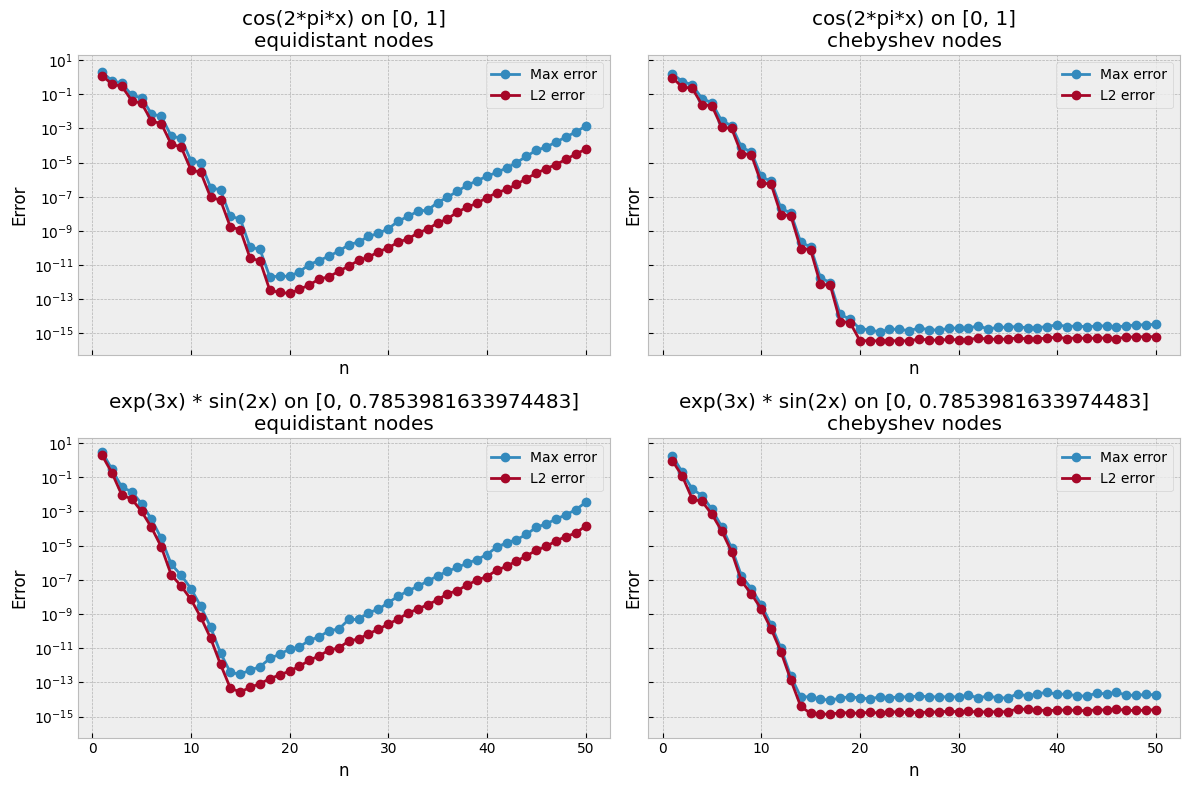

In [10]:
plot_convergence([(f_cos, 0, 1),(f_expsin, 0, np.pi/4)], 1, 50)

Our numerical results do not align with the theory we have derived. We see that the interpolation starts converging for both functions and both node types. But after a while the `Chevyshev` nodes flatten, while the `Equidistant` nodes start diverging. 

### Error bound for cos(2πx)

Let us specifally look at the max-norm for $\cos(2\pi x)$ and the error bounds we have derived previously.


`Equidistant` nodes. With $h = 1/n$ and $\lVert\pi_{n+1}\rVert_\infty \le h^{n+1}n!/4$:

$$\lVert f_1 - p_n \rVert_\infty
\le \frac{(2\pi)^{n+1}}{(n+1)!}\cdot\frac{n!}{4\,n^{n+1}}
= \frac{1}{4(n+1)}\left(\frac{2\pi}{n}\right)^{n+1}$$

`Chebyshev` nodes. With $\lVert\pi_{n+1}\rVert_\infty \le 2^{-2n-1}$:

$$\lVert f_1 - p_n \rVert_\infty
\le \frac{(2\pi)^{n+1}}{(n+1)!}\cdot\frac{1}{2^{2n+1}}
= \frac{2}{(n+1)!}\left(\frac{\pi}{2}\right)^{n+1}$$

We plot the estimated errors along with the theoretical bound for both node types. In addition we print the numerical values for the erros along with the ratio in between them for every 5th interpolation.

In [11]:
def max_error_cos(n):
    """
    Compute the maximum error bounds for the cos function using equidistant and Chebyshev nodes.
      
    Parameters:
    n (int): The number of interpolation points.

    Returns:
    tuple: A tuple containing the maximum error bounds for equidistant and Chebyshev nodes.
    """
    Mn = (2 * np.pi) ** (n + 1)
    h = 1.0 / n                                  #
    pimax_equidistant = factorial(n) * h ** (n + 1) / 4
    pimax_chebyshev = 1 / (2 ** (2 * n + 1))
    return (Mn * pimax_equidistant / factorial(n + 1), Mn * pimax_chebyshev / factorial(n + 1))


def plot_convergece_cos_error_bound(n0, n_end, n_step=1):
    """
    Plot the maximum error bounds for the cosine function using equidistant and Chebyshev nodes.

    Parameters:
    n0 (int): The starting value of n for interpolation.
    n_end (int): The ending value of n for interpolation.
    n_step (int): The step size for the range of n values.
    """


    # Create an array of n values to use for interpolation
    n_vals = np.arange(n0, n_end + 1, n_step)

    # Create a list of n values for printing
    nprintvals = [n for n in n_vals if n % 5 == 0]

    # lists to store errors
    max_error_equidistant_theoretical = []
    max_error_chebyshev_theoretical = []
    max_error_equidistant_empirical = []
    max_error_chebyshev_empirical = []

    # loop over the values of n to compute the theoretical and empirical maximum errors
    for n in n_vals:
        error_equidistant, error_chebyshev = max_error_cos(n)
        max_error_equidistant_theoretical.append(error_equidistant)
        max_error_chebyshev_theoretical.append(error_chebyshev)
        error_equidistant_empirical, _ = convergence(f_cos, 0, 1, [n], nodes="equidistant")
        error_chebyshev_empirical, _ = convergence(f_cos, 0, 1, [n], nodes="chebyshev")
        max_error_equidistant_empirical.append(error_equidistant_empirical[0])
        max_error_chebyshev_empirical.append(error_chebyshev_empirical[0])
        if n in nprintvals:
            print(f"n = {n}: Max error bound (equidistant) = {error_equidistant:.2e}, Max error bound (Chebyshev) = {error_chebyshev:.2e}")
            print(f"n = {n}: Max error empirical (equidistant) = {error_equidistant_empirical[0]:.2e}, Max error empirical (Chebyshev) = {error_chebyshev_empirical[0]:.2e}")
            print(f"n = {n}: Ratio (empirical/theoretical) (equidistant) = {error_equidistant_empirical[0]/error_equidistant:.2e}, Ratio (empirical/theoretical) (Chebyshev) = {error_chebyshev_empirical[0]/error_chebyshev:.2e}")
            print("-" * 80)


    plt.figure(figsize=(10, 6))
    plt.semilogy(n_vals, max_error_equidistant_empirical, label="Equidistant nodes (empirical)", marker='o', linestyle='dashed')
    plt.semilogy(n_vals, max_error_chebyshev_empirical, label="Chebyshev nodes (empirical)", marker='o', linestyle='dashed')
    plt.semilogy(n_vals, max_error_equidistant_theoretical, label="Equidistant nodes", marker='o')
    plt.semilogy(n_vals, max_error_chebyshev_theoretical, label="Chebyshev nodes", marker='o')
    plt.xlabel("n")
    plt.ylabel("Maximum Error Bound")
    plt.title("Maximum Error Bounds for cos(2*pi*x) Interpolation")
    plt.legend()
    plt.grid(True)
    plt.show()

n = 5: Max error bound (equidistant) = 1.64e-01, Max error bound (Chebyshev) = 4.17e-02
n = 5: Max error empirical (equidistant) = 6.26e-02, Max error empirical (Chebyshev) = 3.20e-02
n = 5: Ratio (empirical/theoretical) (equidistant) = 3.82e-01, Ratio (empirical/theoretical) (Chebyshev) = 7.66e-01
--------------------------------------------------------------------------------
n = 10: Max error bound (equidistant) = 1.37e-04, Max error bound (Chebyshev) = 7.20e-06
n = 10: Max error empirical (equidistant) = 1.31e-05, Max error empirical (Chebyshev) = 1.54e-06
n = 10: Ratio (empirical/theoretical) (equidistant) = 9.59e-02, Ratio (empirical/theoretical) (Chebyshev) = 2.13e-01
--------------------------------------------------------------------------------
n = 15: Max error bound (equidistant) = 1.40e-08, Max error bound (Chebyshev) = 1.31e-10
n = 15: Max error empirical (equidistant) = 5.09e-09, Max error empirical (Chebyshev) = 1.15e-10
n = 15: Ratio (empirical/theoretical) (equidistan

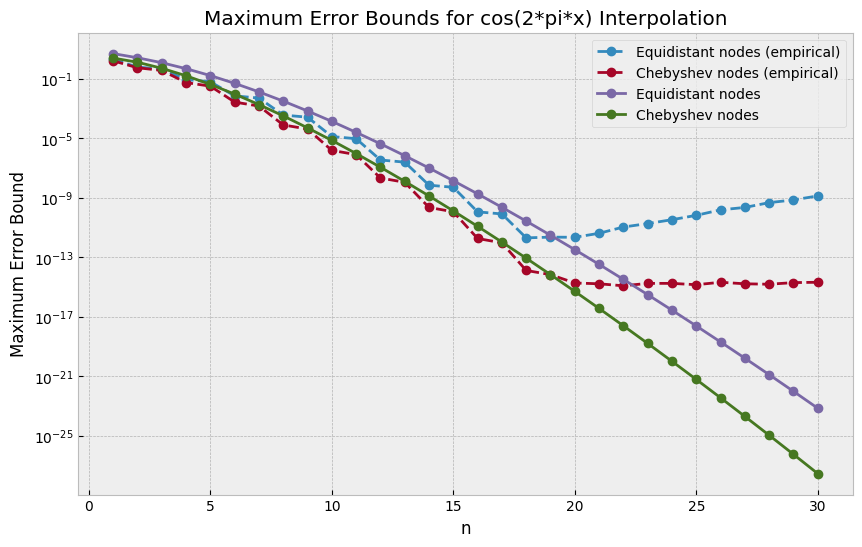

In [12]:
plot_convergece_cos_error_bound(1,30)

### Round-off error and tightness of the bound

The theoretical bound seems to hold until around n = 18. Afterwards it starts following a different trend. This error can be assumed to be due to numerical error. When interpolating a function $f$ we do not find the exact $p_n$ that interpolates the function. There is floating point errors for the nodes, the evaluation of the function, and the actual interpolation evaluation. Meaning that we actually find an approximate funcion to $p_n$ that we call $\hat p_n$. What we are actually "measuring" is:
$$||f-\hat p_n||_{\infty} \leq ||f-p_n||_{\infty} + ||p_n-\hat p_n||_{\infty}$$

This, in addition to the error being an approximation that will not give you values below machine precision, is what most likely gives us the error we observe. There must be something with how the nodes are created that affect $||p_n-\hat p_n||_{\infty}$, where `Equidistant` nodes have the error increasing exponentially with n.

Note that it could very well be that the error from the `Chebyshev` nodes also increase, but just at such a slow rate that we need an absurd amount of nodes to observe it.

The theoretical bound of errors can in many cases be too relaxed, meaning that the error is usually so much lower than what the bound gives, making the bound less usefull. We can look at this for the two different node types. We have printed out the errors, theoretical bounds and the ratio between them for $n \in [5,10,15,20,25,30]$. The last three values are not viable due to the error previously discussed, and therefore we will not look at them. Before moving forward notice how the the error follows a stair pattern with only a substansial decrease for even values of $n$. This result can be accredited to the polynomial expansion of $\cos$ only having even terms. Therefore we need to look at the error for even and odd values of $n$ seperately. For $n \in [5,15]$ the error is around $30-40\%$ of the theoretical bound for `equidistant` nodes and $80\%$ for `Chebyshev` nodes. While for $n=10$ it drops to around $10\%$ and $20\%$ respectively. In our case, this result suggests that the bound for `Chebyshev` is a better bound since it is stricter than the one for `equidistant`. Since both bounds use the same max on the derivative we can assume that the bound on $pi(x)$ is a better bound for `Chevyshev` than for `equidistant`. 

It is difficult to say what bound is the source of the error. We are bounding both the derivative and $\pi(x)$ at the same time. But we are not guaranteed that they achive their maximum at the same points. Our bound on the derivative and $\pi(x)$ for `Chebyshev` is exact. So in this case it is hard to know what fails, but $\pi(x)$ does not need to hit its maximum value. Suggesting that for `Equidistant` nodes the main gap is explained by the bound on $\pi(x)$

The bounds for the two different methods also give different values. The bound for `Chebyshev` nodes go faster to zero than for `equidistant` nodes. Showing that the bound on $pi_{n+1}$ for `Chebyshev` is a stricter bound than the one for `equidistant`.

## <a id="task-c" name="task-c"></a>1c) Piecewise polynomial interpolation

### Implementation

In [13]:
def make_piecewise(f, a, b, K, n=5, nodes="equidistant",noise = 0):
    """
    Create a piecewise Lagrange interpolating function for a given function f on the interval [a, b] using K subintervals and n intervals per subinterval with specified node type.

    Parameters
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    K (int): The number of subintervals.
    n (int): The number of intervals per subinterval.
    nodes (str): The type of nodes to use ("equidistant" or "chebyshev").
    noise (float): The standard deviation of Gaussian noise to add to the evaluation points.

    Returns
    callable: The piecewise Lagrange interpolating function.
    """

    # create the subintervals and get the nodes for each subinterval
    v = np.linspace(a, b, K + 1)

    # create a list of nodes for each subinterval and evaluate the function at those nodes
    xs = [get_nodes(nodes, v[k], v[k + 1], n) for k in range(K)]
    ys = [np.asarray(f(xk), dtype=float) for xk in xs]


    # add noise to the evaluation points if specified. Mainly used in 1c for stability tests.
    if noise > 0:
        for k in range(K):
            ys[k] += np.random.normal(0, noise, size=ys[k].shape)*ys[k]

    # create the piecewise Lagrange interpolating function
    # use masks to determine which subinterval the input x belongs to and evaluate the corresponding Lagrange polynomial
    # looping whould increase runtime and lessen the performance of the function
    def g(x):
        out = np.zeros_like(x, dtype=float)
        for k in range(K):
            upper = (x <= v[k + 1]) if k == K - 1 else (x < v[k + 1])
            mask = (x >= v[k]) & upper
            if np.any(mask):
                out[mask] = lagrange_eval(xs[k], ys[k], x[mask])
        return out

    # attributes for easy access to the nodes, function, and interval
    g.nodes = np.unique(np.concatenate(xs))
    g.label = f"K = {K}, n = {n} ({nodes})"
    g.function = f       
    g.interval = (a, b)   
    return g


def convergence_piecewise(f, a, b, K_vals, n, nodes="equidistant", N=1000):
    """
    Compute the convergence errors for a given function f on the interval [a, b] using piecewise Lagrange interpolation with specified node type.

    Parameters:
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    K_vals (array-like): The values of K to use for piecewise interpolation.
    n (int): The number of intervals per subinterval.
    nodes (str): The type of nodes to use for interpolation.
    N (int): The number of points to use for error computation.

    Returns:
    tuple: A tuple containing the maximum errors and the L2 errors.
    """

    # lists to store the maximum and L2 errors for each K
    max_error_list = []
    l2_error_list = []

    # loop over the values of K lant
    for K in K_vals:
        # create the piecewise Lagrange interpolating function for the current K
        g = make_piecewise(f, a, b, K, n, nodes=nodes)

        # compute the maximum and L2 errors for the interpolant g
        max_error, l2_error = error(g)
        max_error_list.append(max_error)
        l2_error_list.append(l2_error)
    return (np.array(max_error_list), np.array(l2_error_list))


def plot_piecewise_convergence(functions, K0, K_end,n_vals = [5], K_step=1,nodes = ["equidistant", "chebyshev"], N=1000):
    """
    Plot convergence errors for piecewise Lagrange interpolation for multiple functions and node types.

    Parameters:
    functions (list): A list of tuples containing the function, left endpoint, and right endpoint. (f, a, b)
    K0 (int): The starting value of K for interpolation.
    K_end (int): The ending value of K for interpolation.
    n_vals (list): A list of integers representing the number of intervals per subinterval.
    K_step (int): The step size for the range of K values.
    nodes (list): A list of strings representing the types of nodes to use for interpolation.
    N (int): The number of points to use for error computation.

    Returns:
    None
    """

    # Create an array of K values to use for piecewise interpolation
    K_vals = np.arange(K0, K_end + 1, K_step)

    # Create a grid of subplots for each function and node type
    fig, axes = plt.subplots(
        len(functions),
        len(nodes),
        figsize=(12 * len(nodes), 8 * len(functions)),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    # Loop over each function and node type to compute and plot the convergence errors
    for row, (f, a, b) in enumerate(functions):
        for col, node_type in enumerate(nodes):
            ax = axes[row, col]

            # loop over the values of n to compute the convergence errors for each n
            for n in n_vals:
                max_error, l2_error = convergence_piecewise(
                    f, a, b, K_vals, n, nodes=node_type, N=N
                )

                ax.semilogy(
                    K_vals,
                    max_error,
                    marker="o",
                    label=f"Max error, n={n}",
                )
                ax.semilogy(
                    K_vals,
                    l2_error,
                    marker="s",
                    linestyle="--",
                    label=f"L2 error, n={n}",
                )

            ax.set_title(
                f"{f.__name__} on [{a}, {b}]\n"
                f"{node_type} nodes"
            )
            ax.set_xlabel("K")
            ax.set_ylabel("Error")
            ax.grid(True)
            ax.legend()

    fig.tight_layout()
    plt.show()

### Introduction and visualization

An alternative to finding a polyniomial of degree $n$ that interpolates the $n+1$ nodes is dividing the nodes into subsections, the number of such subsections we will denote by $K$ and number of nodes in each subsection with $n$ (not to be confused with our original $n$). A piecewise interpolation with `equidistant` nodes with $K = 3, n=2$ is plotted down below to give an intuitive understanding of how a piecewise interpolation works.

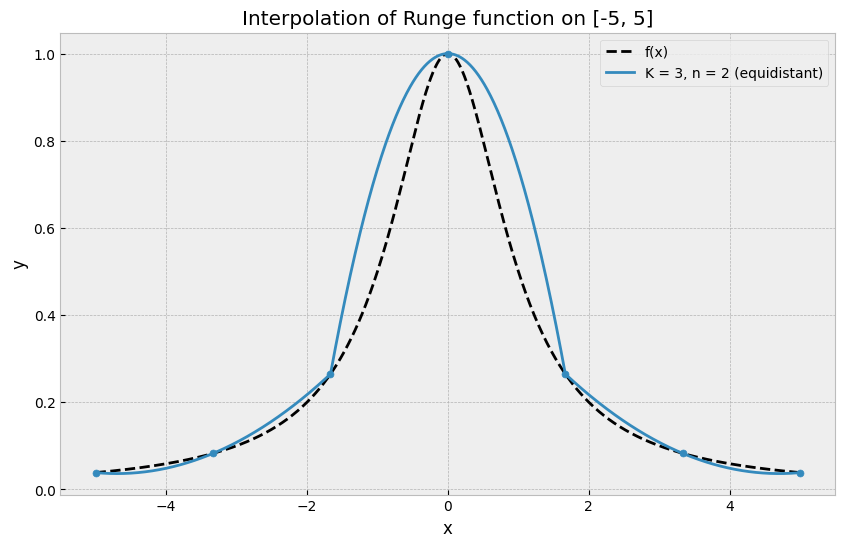

In [14]:
test = make_piecewise(runge, -5, 5, 3, 2)
plot_interpolant(-5,5,test)

### Error analysis

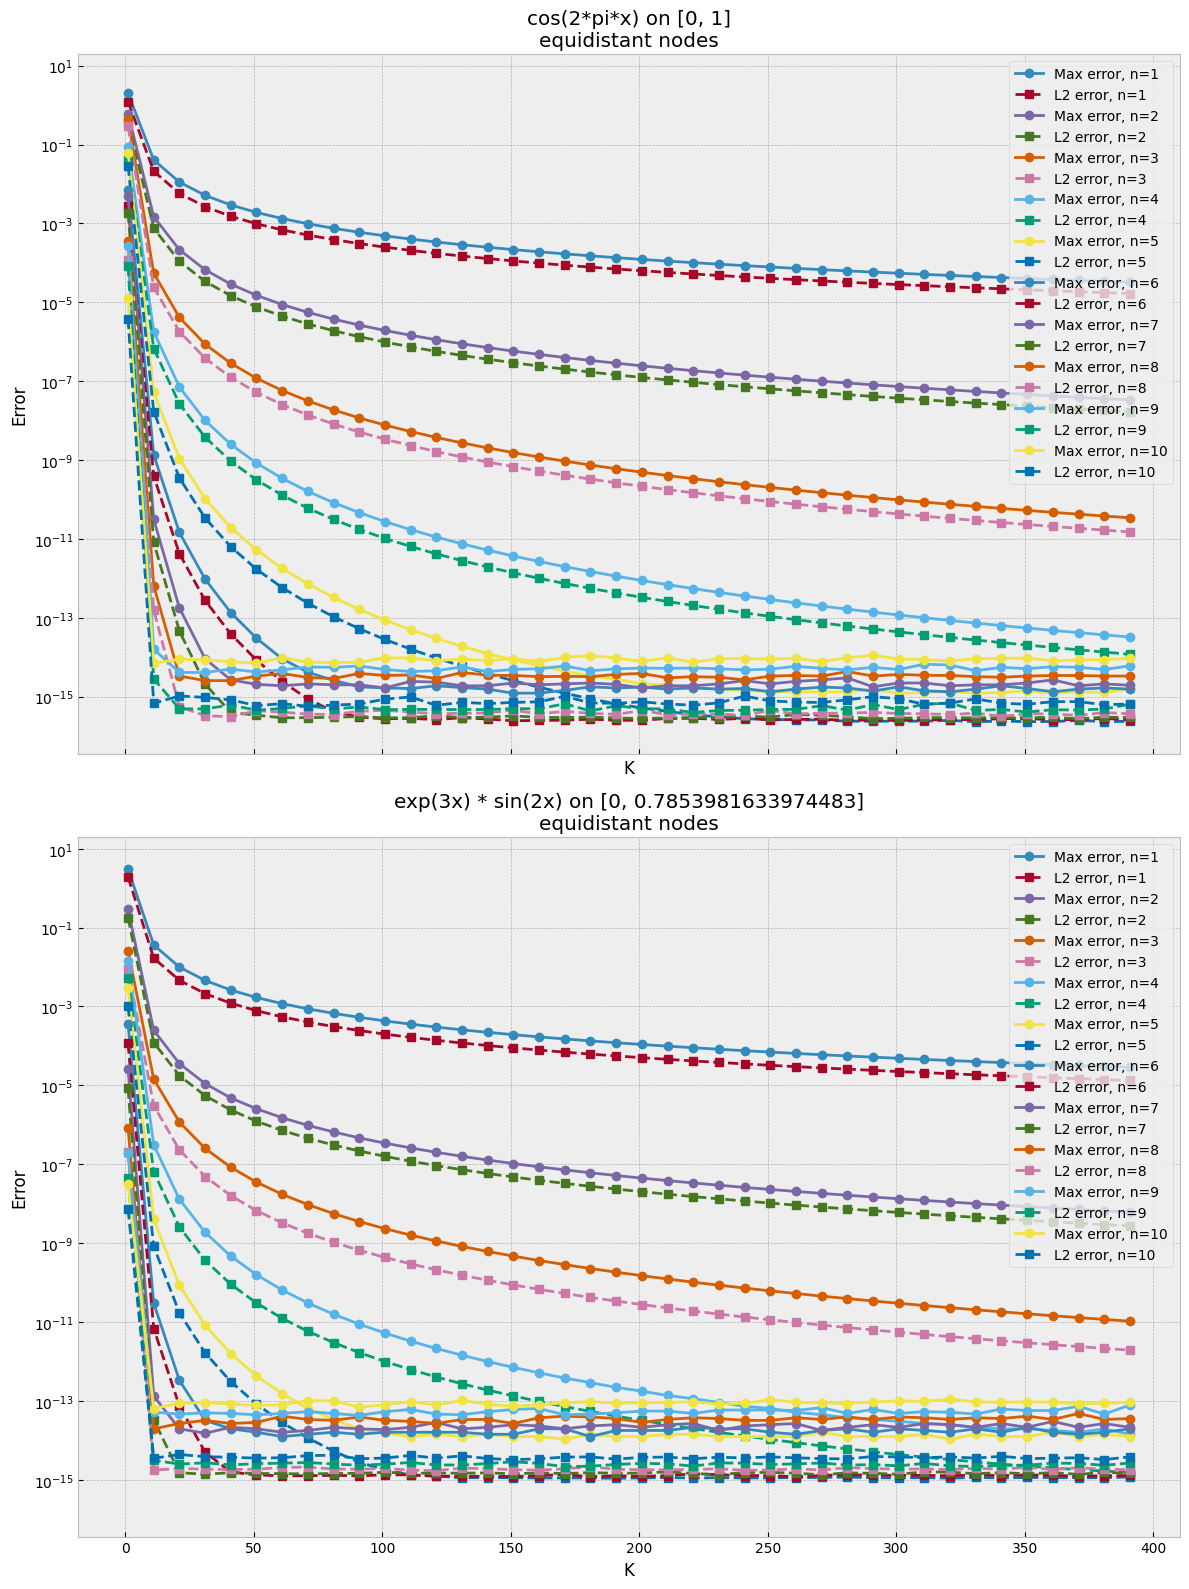

In [15]:
plot_piecewise_convergence([(f_cos, 0, 1),(f_expsin, 0, np.pi/4)], 1, 400,K_step = 10,nodes = ["equidistant"], n_vals = [1,2,3,4,5,6,7,8,9,10])

Above we have plotted the approximation of the max and $L_2$-error for the piecewise interpolation for different values of $n$ as functions of $K$. We see that every interpolation converges, but the speed is based on the number of nodes. This plot is too cluttered to do any real analysis, so we fix $n=5$ for further analysis.

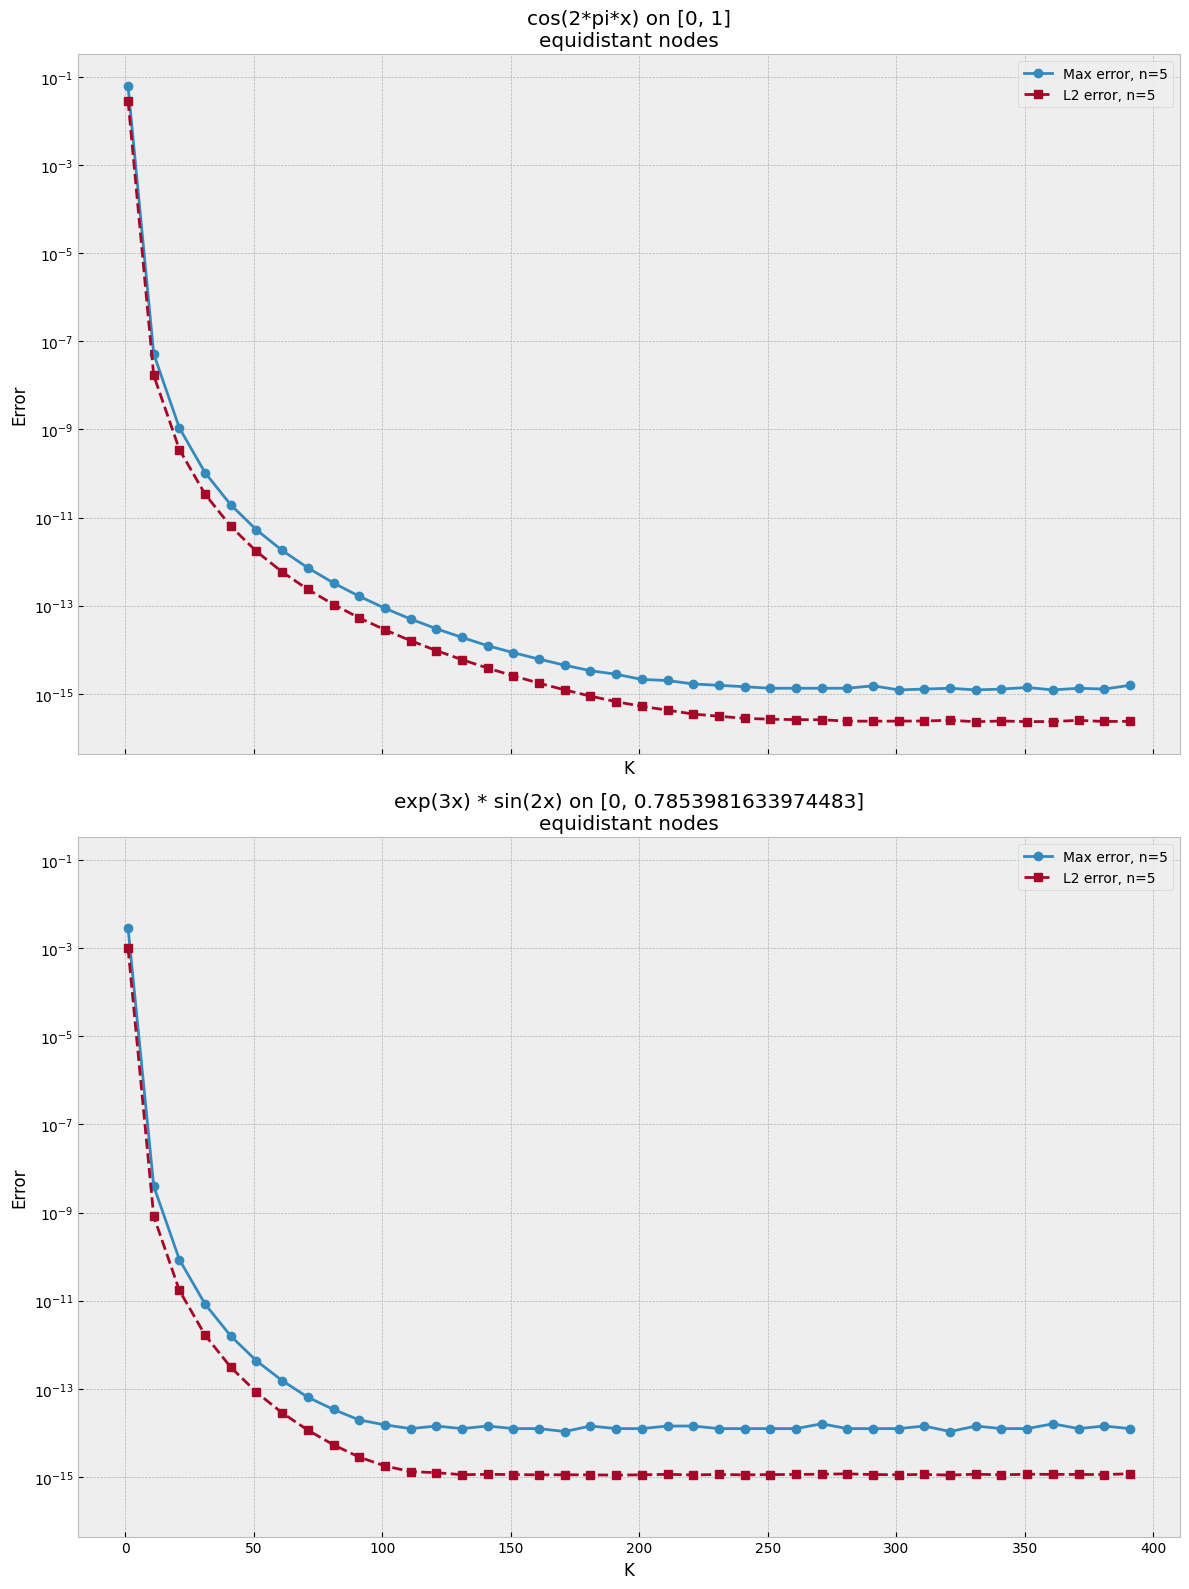

In [16]:
plot_piecewise_convergence([(f_cos, 0, 1),(f_expsin, 0, np.pi/4)], 1, 400,K_step = 10,nodes = ["equidistant"])

We see that the error converges to the same errors that regular interpolation with `Chebyshev` nodes did, strengthing the theory that this is just how close an interpolation can come before being limited by floating point errors.

The nodes that are interpolated over are equidistant, but we do not see the the same blow up that came when using regular interpolation. This suggests that this method is a more stable method compared to regular interpolation. And therefore more adventagous when we can not choose our interpolation nodes.

This method may be more stable, and converge to zero, but requires a larger amount of nodes. Remember that for $K$ subsections we need $Kn$ nodes. To get the same error as we got for $21$ `Chebyshev` nodes we require $K=100$, and therefore $501$ nodes. $25$ times the nodes to get the same error.

This suggests that piecewise interpolation is a surperior method in cases where we have access to a large amount of interpolation points without them necessarily being idealy placed.

### Runtime analysis

In [17]:
def time_interpolation(g, x_eval):
    """
    Measure the time taken to evaluate the interpolating polynomial g at points x_eval.

    Parameters:
    g (callable): The interpolating polynomial function.
    x_eval (ndarray): The points at which to evaluate the interpolating polynomial.

    Returns:
    float: The time taken in seconds to evaluate the interpolating polynomial.
    """
    # Measure the time taken to evaluate the interpolating polynomial g at points x_eval
    start_time = time.time()
    g(x_eval)
    end_time = time.time()

    # return the time taken in seconds
    return end_time - start_time

def plot_time_interpolation(
    f, a, b,
    n0, n_end,
    K0, K_end,
    n_step=1,
    K_step=1,
    piecewise_n=5,
    N=1000,
    noise = 0
):
    """
    Plot the error and runtime of global and piecewise Lagrange interpolation for a given function f on the interval [a, b].

    Parameters:
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    n0 (int): The starting value of n for global interpolation.
    n_end (int): The ending value of n for global interpolation.
    K0 (int): The starting value of K for piecewise interpolation.
    K_end (int): The ending value of K for piecewise interpolation.
    n_step (int): The step size for the range of n values.
    K_step (int): The step size for the range of K values.
    piecewise_n (int): The number of intervals per subinterval for piecewise interpolation.
    N (int): The number of points to use for error computation.
    noise (float): The amount of noise to add to the function values.
    """

    # Create arrays of n and K values to use for interpolation
    n_vals = np.arange(n0, n_end + 1, n_step)
    K_vals = np.arange(K0, K_end + 1, K_step)
    x_eval = np.linspace(a, b, N)

    # Lists to store errors and runtimes for each interpolation method
    errors_equidistant = []
    times_equidistant = []
    errors_chebyshev = []
    times_chebyshev = []
    errors_piecewise = []
    times_piecewise = []

    # Global equidistant interpolation
    for n in n_vals:
        interpolant = make_lagrange(
            f, a, b, n, nodes="equidistant", noise=noise
        )
        times_equidistant.append(
            time_interpolation(interpolant, x_eval)
        )
        errors_equidistant.append(error(interpolant)[0])

    # Global Chebyshev interpolation
    for n in n_vals:
        interpolant = make_lagrange(
            f, a, b, n, nodes="chebyshev", noise=noise
        )
        times_chebyshev.append(
            time_interpolation(interpolant, x_eval)
        )
        errors_chebyshev.append(error(interpolant)[0])

    # Piecewise equidistant interpolation
    for K in K_vals:
        interpolant = make_piecewise(
            f, a, b, K,
            n=piecewise_n,
            nodes="equidistant",noise=noise
        )
        times_piecewise.append(
            time_interpolation(interpolant, x_eval)
        )
        errors_piecewise.append(error(interpolant)[0])

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        sharey=True
    )

    runtime_axes = [axis.twinx() for axis in axes]

    # Error curves
    axes[0].semilogy(
        n_vals, errors_equidistant,
        "o-", color="C0", label="Error"
    )
    axes[1].semilogy(
        n_vals, errors_chebyshev,
        "o-", color="C0", label="Error"
    )
    axes[2].semilogy(
        K_vals, errors_piecewise,
        "o-", color="C0", label="Error"
    )

    # Runtime curves
    runtime_axes[0].semilogy(
        n_vals, times_equidistant,
        "s--", color="C1", label="Runtime"
    )
    runtime_axes[1].semilogy(
        n_vals, times_chebyshev,
        "s--", color="C1", label="Runtime"
    )
    runtime_axes[2].semilogy(
        K_vals, times_piecewise,
        "s--", color="C1", label="Runtime"
    )

    axes[0].set_title("Equidistant interpolation")
    axes[1].set_title("Chebyshev interpolation")
    axes[2].set_title("Piecewise equidistant interpolation")

    axes[0].set_xlabel("n")
    axes[1].set_xlabel("n")
    axes[2].set_xlabel("K")

    axes[0].set_ylabel("Error")
    axes[0].grid(True)

    # Make all runtime axes use the same y-scale
    all_times = np.concatenate([
        times_equidistant,
        times_chebyshev,
        times_piecewise
    ])

    positive_times = all_times[all_times > 0]
    runtime_min = positive_times.min()
    runtime_max = positive_times.max()

    for runtime_axis in runtime_axes:
        runtime_axis.set_ylim(
            runtime_min / 2,
            runtime_max * 2
        )
        runtime_axis.set_ylabel("Runtime [s]")

    # Combined legends
    for axis, runtime_axis in zip(axes, runtime_axes):
        handles_1, labels_1 = axis.get_legend_handles_labels()
        handles_2, labels_2 = runtime_axis.get_legend_handles_labels()

        axis.legend(
            handles_1 + handles_2,
            labels_1 + labels_2,
            loc="best"
        )

    fig.suptitle(f"{f.__name__}")
    fig.tight_layout()
    plt.show()

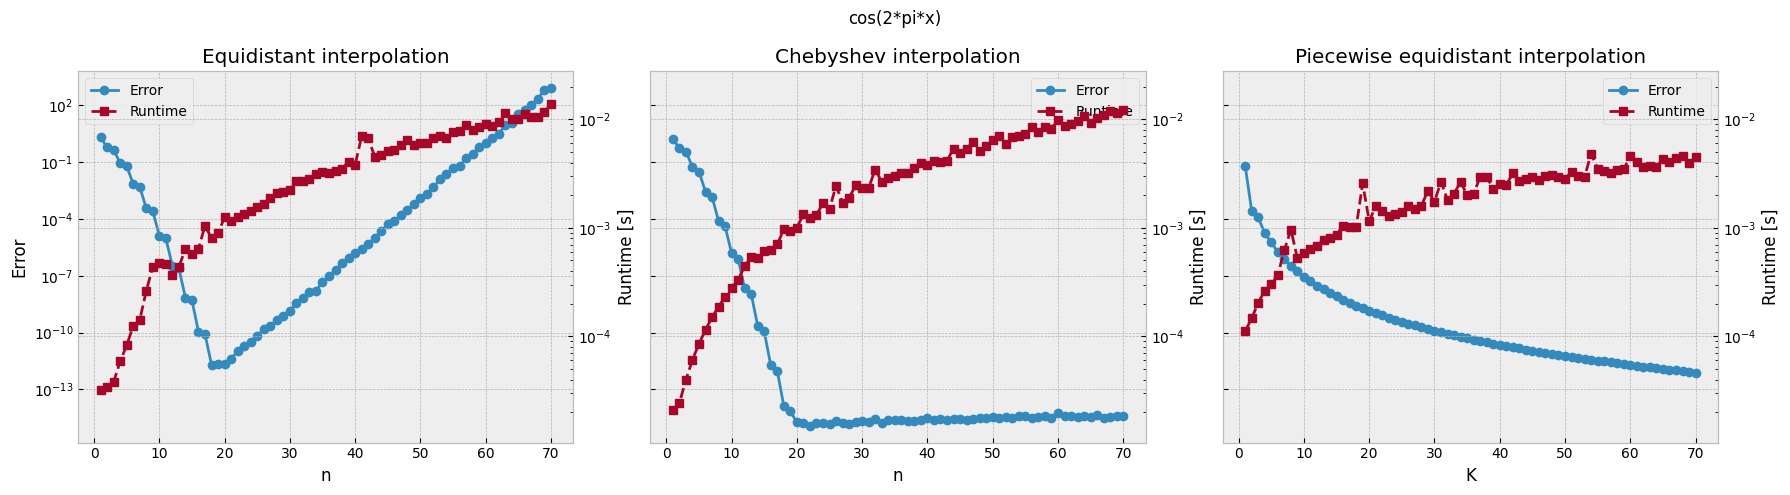

In [18]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=70,
    K0=1, K_end=70
)

Up intil now we have only looked at the error of our approximation, but runtime of interpolation is an important factor as well. Above we have plotted error and runtime for all the different interpolation methods we have looked at so far. The plots share a y-axis making it easy to compare. Important to note that piecewise interpolation is a function of $K$ while the others are functions of $n$. 

The obvious part is that the runtime of piecewise interpolation is faster than the other methods for the same number of nodes. For $n=50$ the regular interpolations have a runtime right under $10^{-2}$ seconds, while piecewise is right under $10^{-3}$ seconds (for $K=10$). A tenth of the runtime. This can be explained by use of $\mathcal{O}$-notation. To avoid confusion with notation we switch the $n$ in piecewise with $m$. Also note that $K = n/m$. For regular interpolation one loops over $n+1$ nodes, where for each iteration $n+1$ calculations are done. Making the runtime be $\mathcal{O}(n^2)$. Piecwise first finds the subsection that corresponds to the point, which takes $\mathcal{O}(K)$ time. Once the the section is found, $(m+1)^2$ calculations are done. Making the runtime be $\mathcal{O}(K+m^2) = \mathcal{O}(K) = \mathcal{O}(n)$. Suggesting that for a large amount of nodes piecewise is a better method to avoid high runtimes.

What if we want a fast interpolation that gives us a max-error of $10^{-10}$, what method is best? By reading of the plot we get approximate times:
- `Equidistant`: $10^{-3}$ s
- `Chebyshev`: $10^{-3.4}$ s
- `Piecewise`: $10^{-2.7}$ s

To achive the same precision as the regular interpolation piecewise needs a significantly longer runtime. But what if instead we are satisfied with a higher error of $10^{-4}$. Then the different methods have similiar runtime, suggesting that piecewise could be a better method when super precise interpolation is not needed. E.g. where other factors of error will make all interpolations with low enough error equal.


### Stability under noise

In [19]:
#fixed random seed so that the noisy experiments below are reproducible
np.random.seed(0)

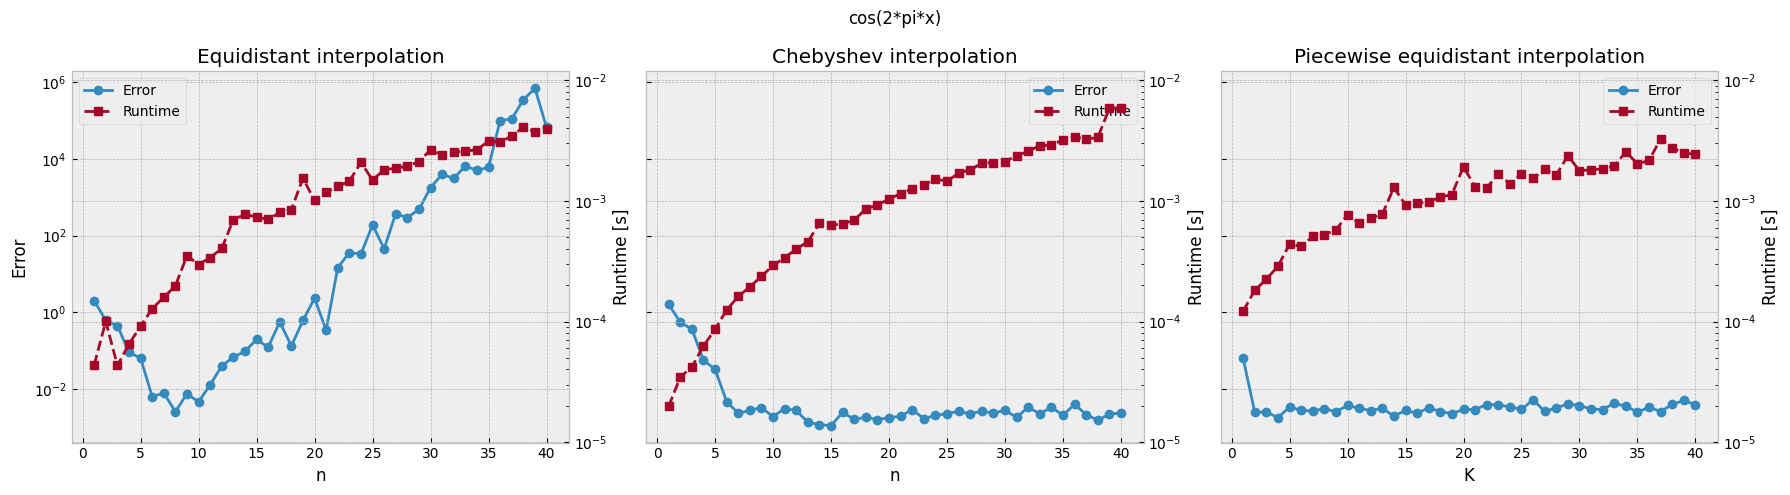

In [20]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.001
)

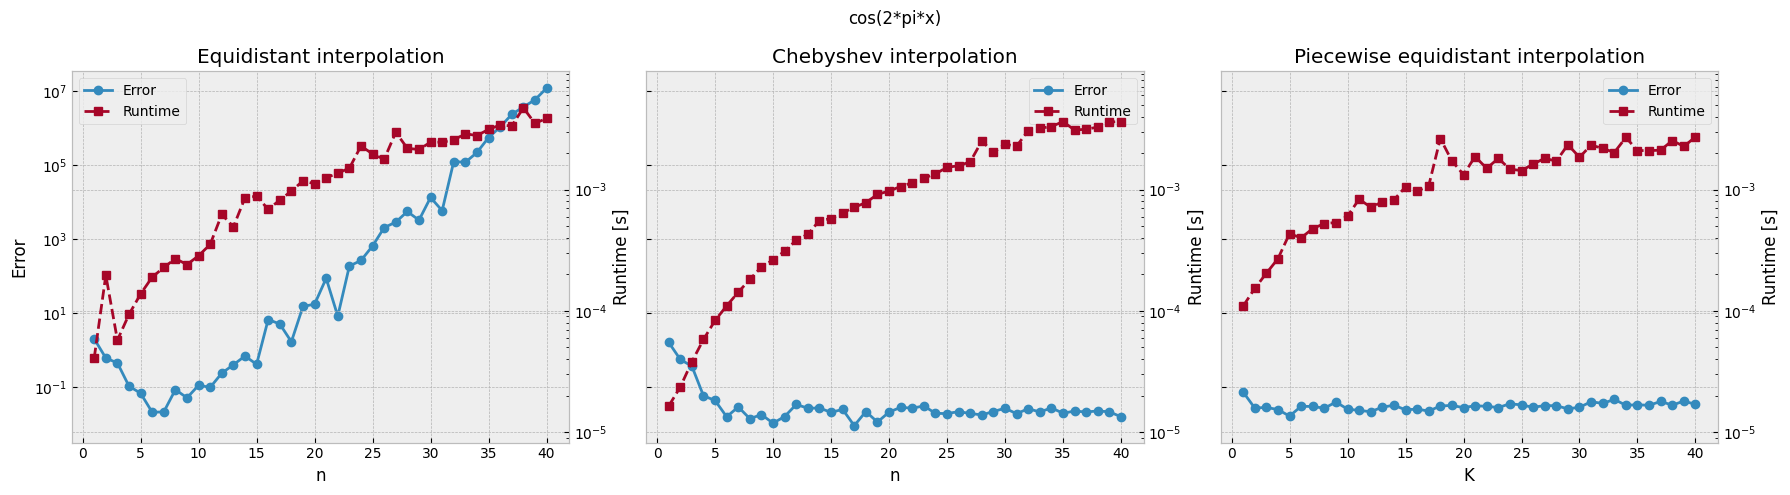

In [21]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.01
)

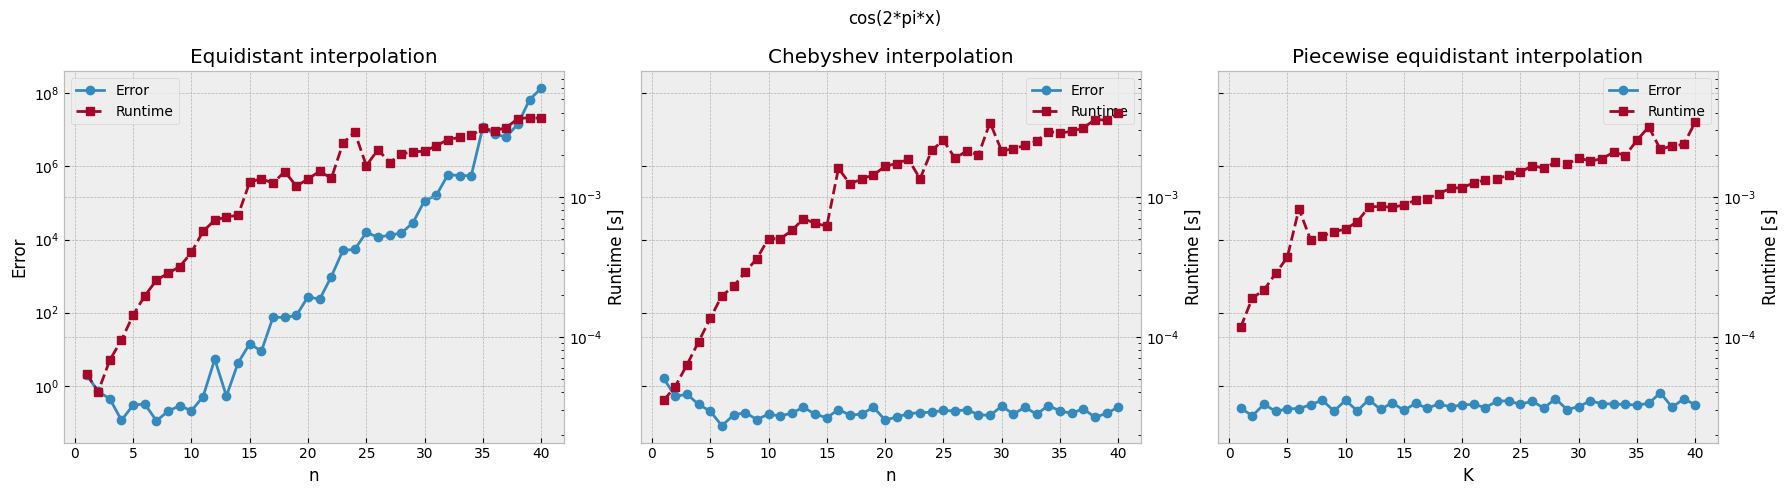

In [22]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.1
)

To get a deeper insight into the stability of our methods we have done the interpolation again, but now added noise to the y-values we interpolate over. The noise is a percentage of the y-value. Above we have plotted max-error and runtime for all three methods but added $0.1\%$, $1\%$ and $10\%$ noise to the interpolated values. This is to simulate a real world situation where measurments are noisy.

Regular interpolation with has the same pattern as before. both node types give quick convergence, but `equidistant` nodes start diverging and `chebyshev` flatten out. Higher noise lifts the minimum error as one whould expect, so we do not get the same extreme precission. 

An important result of this higher minimum error is that piecewise interpolation reaches maximum precission almost immediatly. Since the noise makes hyper precise interpolation impossible, `Chebyshev` no longer has this advantage over piecewise. This in addition to the slower growing runtime suggests that piecewise is a better method for noisy-real world data.

### Conclusion

In conclusion; piecewise interpolation has its advantages over regular interpolation. In cases where there are small sources of noise and we can pick our nodes as we please, regular interpolation with `Chebyshev` nodes is the clear winner. It has higher asymptotic runtime than piecewise, but since it can reach extreme precision in such few amount of nodes it does not really matter. 

This is rarely the case. Most sampling in the real world is done with equidistant nodes (e.g. stock markets, frequency analysis). And most real world cases suffer from noise and non-clean functions. In these cases the instability and larger runtimes of regular interpolation makes piecewise interpolation a better method due to its inherent stability and low comparably low runtimes. 

## <a id="task-d" name="task-d"></a>1d) Radial basis function (RBF) interpolation

### Implementation

In [23]:
# functions to interpolate, define and name them for plotting and ease of use
# created new functions for torch, since the original ones were not compatible with torch tensors
# instead of having to rewrite the entire interpolation code, I created new functions that are compatible with torch tensors
def runge_torch(x):
    """f(x) = 1 / (1 + x^2)."""
    return 1.0 / (1.0 + x**2)
runge_torch.__name__ = "Runge function"

def f_cos_torch(x):
    """f(x) = cos(2*pi*x)"""
    return torch.cos(2 * torch.pi * x)
f_cos_torch.__name__ = "cos(2*pi*x)"

def f_expsin_torch(x):
    """f(x) = exp(3x) * sin(2x)"""
    return torch.exp(3 * x) * torch.sin(2 * x)
f_expsin_torch.__name__ = "exp(3x) * sin(2x)"

In [24]:
def phi(r2, epsilon):
    # NOTE: takes the SQUARED distance r2 = r**2, not r.
    # phi(r) = exp(-(eps*r)^2) = exp(-eps^2 * r2), so |.| is never formed.
    return torch.exp(-(epsilon**2) * r2)

def M_create(x, epsilon):
    """ 
    Create the interpolation matrix M for RBF interpolation.
    
    parameters:
    x (torch.Tensor): The input tensor of shape (N,) containing the interpolation nodes.
    epsilon (float): The shape parameter for the radial basis function.

    returns:
    torch.Tensor: The interpolation matrix M of shape (N, N).

    """

    # Note the the avoidance of using absolute values
    r2 = (x[:, None] - x[None, :])**2
    return phi(r2, epsilon)

def RBF_interpolation(x, x_nodes, weights, epsilon):
    # Note the the avoidance of using absolute values
    r2 = (x[:, None] - x_nodes[None, :])**2
    return torch.matmul(phi(r2, epsilon), weights)

def weights_create(x,f, epsilon):
    # Create the weights for RBF interpolation.
    y = f(x)
    M = M_create(x, epsilon)
    return torch.linalg.solve(M, y)


def RBF_interpolation_task(x,x_nodes,y,epsilon):
    # NOTE: This function is only created for the task.
    # NOTE: It is more efficient to create the weights once and then use them for multiple evaluations of the interpolation function.
    M = M_create(x_nodes, epsilon)   
    weights = torch.linalg.solve(M, y)
    return RBF_interpolation(x, x_nodes, weights, epsilon)


def create_RBF_interpolator(x_nodes, f, epsilon, interval=None):
    """
    Create a callable RBF interpolator function for a given function f on the interval defined by x_nodes using the specified shape parameter epsilon.
    
    parameters:
    x_nodes (torch.Tensor): The input tensor of shape (N,) containing the interpolation nodes
    f (callable): The function to interpolate.
    epsilon (float): The shape parameter for the radial basis function.
    interval (tuple, optional): The interval (a, b) for the interpolation.
    
    returns:
    callable: The RBF interpolating function.
    """
    
    weights = weights_create(x_nodes, f, epsilon)
    def g(x):
        return RBF_interpolation(x, x_nodes, weights, epsilon)

    # Add attributes to the function for easy access to the nodes, function, epsilon, and interval
    g.function = f
    g.nodes = x_nodes
    g.epsilon = epsilon
    g.interval = interval
    return g

In [25]:
def plot_RBF_interpolator(f,a,b,n,*epsilons,N=1000):
    """
    Plot the RBF interpolator for a given function f on the interval [a, b] using n intervals and specified shape parameters epsilon.

    parameters:
    f (callable): The function to interpolate.
    a (float): The left endpoint of the interval.
    b (float): The right endpoint of the interval.
    n (int): The number of intervals.
    *epsilons: The shape parameters for the radial basis function.
    N (int): The number of points to use for plotting.
    """
    plt.figure(figsize=(10, 6))
    x_nodes = torch.linspace(a, b, n+1)
    x_plot = torch.linspace(a, b, N)
    for epsilon in epsilons:
        g = create_RBF_interpolator(x_nodes, f, epsilon)
        y_plot = g(x_plot)


        plt.plot(x_plot.numpy(), y_plot.numpy(), label=f"RBF Interpolation (n={n}, ε={epsilon})")
    plt.plot(x_plot.numpy(), f(x_plot).numpy(), label=f"Original Function: {f.__name__}")
    plt.scatter(x_nodes.numpy(), f(x_nodes).numpy(), color='red', zorder=5, label="Interpolation Nodes")
    plt.title(f"RBF Interpolation of {f.__name__} with n={n}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid()
    plt.show()

### Choice of the shape parameter ε

It is possible to interpolate with other functions than the polynomials. A common one is with RBF functions such as:
$$\phi(x) = \exp(-(\epsilon r)^2), \quad r = |x-x_i|$$
The $\epsilon$ value is known as a shape parameter. It determines how fast a $\phi$ centered at $x_i$ decays. To get a better intuition we have plotted the RBF interpolation of the `Runge` function for different values of $\epsilon$.

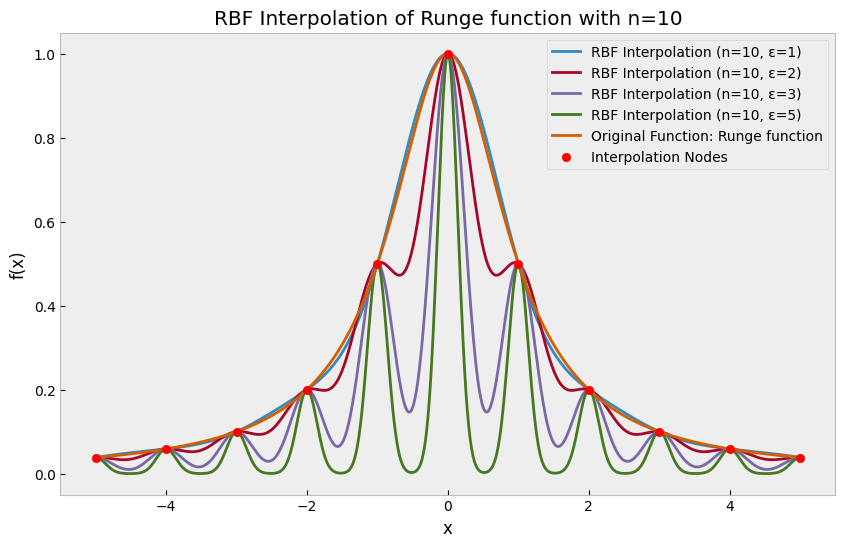

In [26]:
plot_RBF_interpolator(runge_torch,-5,5,10,1,2,3,5)

We clearly see the consequence of having a too large $\epsilon$ value in this plot. The effect of the interpolation in a node dies off before the effect of the next node. But for small enough values the interpolation seems to be really good. What if we have smaller values of  $\epsilon$?

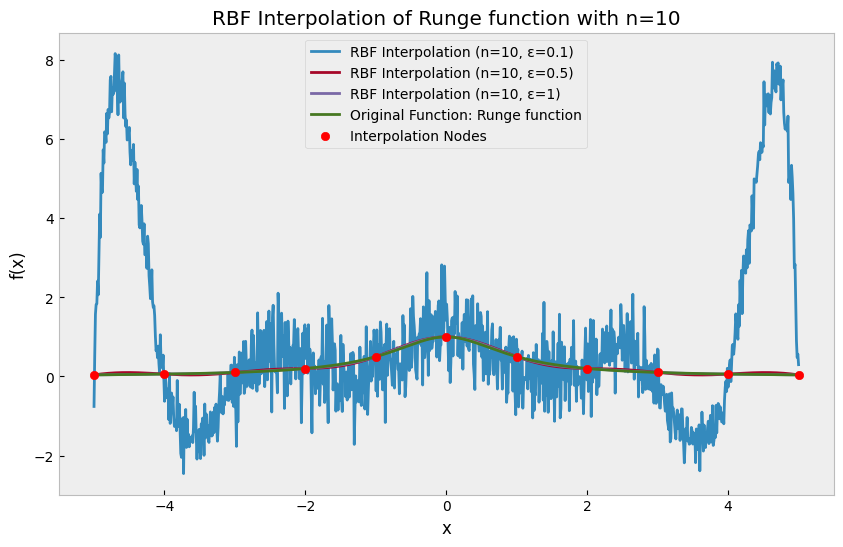

In [27]:
plot_RBF_interpolator(runge_torch,-5,5,10,0.1,0.5,1)

For $\epsilon = 0.5$ we see that the interpolation starts overshooting in a weird way, and for $\epsilon = 0.1$ the interpolation looks to be dominated by random noise. We will look further into the last observation later with condition numbers. But for now $\epsilon = 1$ looks ideal.

So far the `Runge` function is the only one we have considered. What if we start condisering the other functions we have previously looked at?

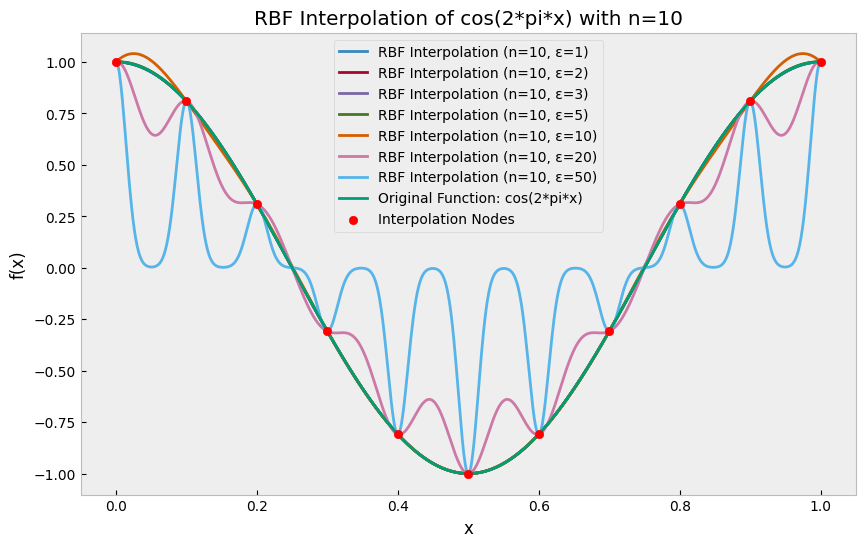

In [28]:
plot_RBF_interpolator(f_cos_torch,0,1,10,1,2,3,5,10,20,50)

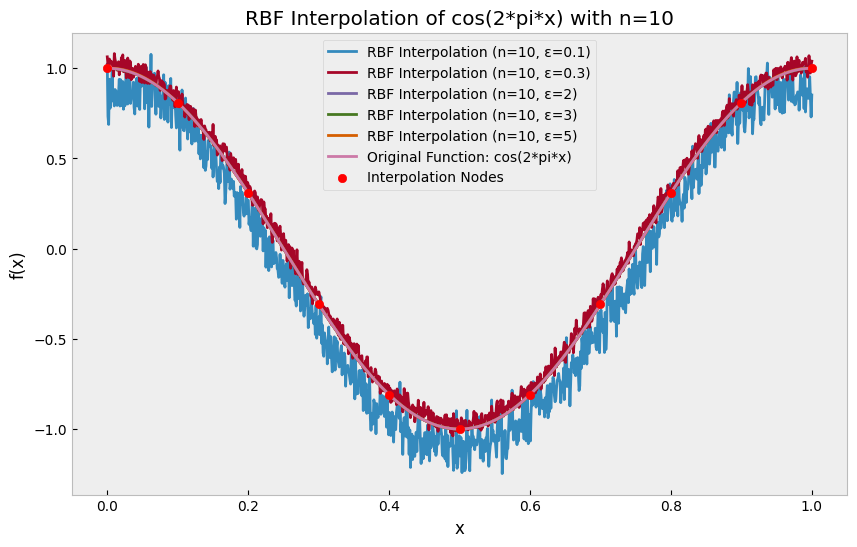

In [29]:
plot_RBF_interpolator(f_cos_torch,0,1,10,0.1,0.3,2,3,5)

$\cos(2\pi)$ reacts differently to the values of $\epsilon$. The noise domination start already at $\epsilon = 1$, which was the previously ideal value. But this function also seems to get good results for way larger values of $\epsilon$, only starting to struggle with $\epsilon = 20$. This can be explained by the tighter grid of nodes. We go from an area of size $10$ to $1$, meaning that the nodes are 10 times as close. Suggesting that $\epsilon$ should be considered with respect to $n$. Here a $\epsilon = 5$ (equivalant to $\epsilon = 0.5$ for the `Runge` function) is ideal. This can be interpreted to mean that an ideal $\epsilon$ value will differ inbetween functions.

The nodes we interpolate over hit excactly the peaks of our function. Could this be the source of the accuracy? To test this we shift our region so that the nodes do not hit the extreme points.

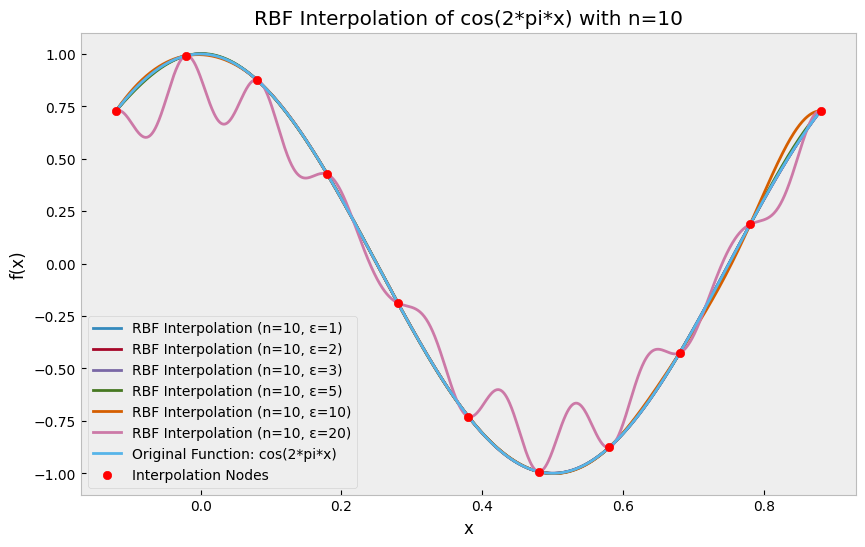

In [30]:
plot_RBF_interpolator(f_cos_torch,-0.12,0.88,10,1,2,3,5,10,20)

We do not see a huge difference, suggesting that the position of the nodes do not have to be ideal for an interpolation to be satisfactory. Of course the position has an effect. If we have 20 nodes on one side and 1 on the other you will get a bad interpolation. But is not a strict requirment. 

To look further into this interpolation we consider $e^{3x}\sin(2x)$

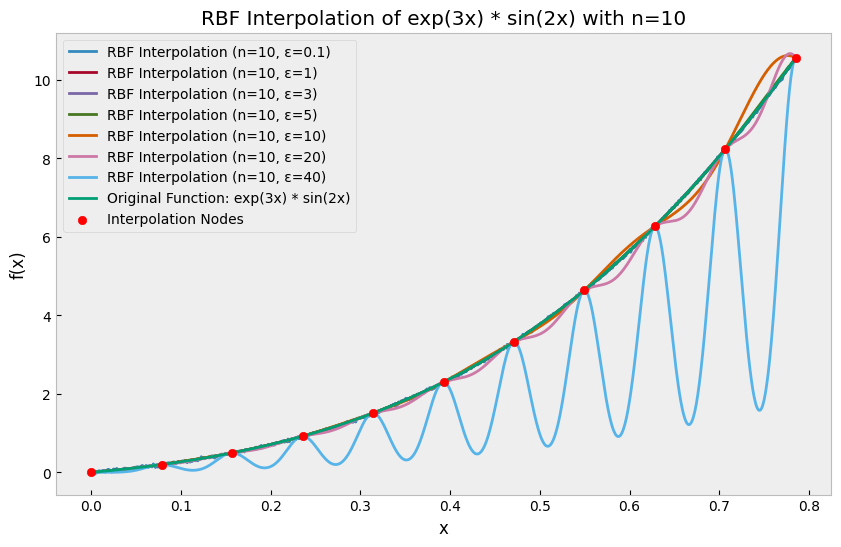

In [31]:
plot_RBF_interpolator(f_expsin_torch,0,torch.pi/4,10,0.1,1,3,5,10,20,40)

Other than the interpolation being "stable" for $\epsilon = 0.1$, nothing seems to be too crazy. This supports the idea that a valid choice of $\epsilon$ needs to take into account the function it is interpolating. A satisfactort $\epsilon$ is around $5$.

### Condition number of M

Our interpolation function of $f$ is expressed in this form:
$$\tilde f(x) = \sum_{i=0}^{n} w_i\, \varphi(|x - x_i|), \qquad \varphi(r) = e^{-(\varepsilon r)^2}$$
 
Where we require:
$$\tilde f(x_i) = f(x_i), \qquad i = 0,\dots,n$$
 
$$\sum_{j=0}^{n} w_j\, \varphi(|x_i - x_j|) = f(x_i), \qquad i = 0,\dots,n$$
 

To find the weights $w_j$ we introduce a distance matrix
$$M_{i,j} := \varphi(|x_i - x_j|)$$
Our interpolation requirments can then be written using matrix notation:
$$Mw = \mathbf f$$
 
$$w = [w_0,\dots,w_n]^T, \qquad \mathbf f = [f(x_0),\dots,f(x_n)]^T$$
 
$$
\begin{bmatrix}
\varphi(|x_0-x_0|) & \cdots & \varphi(|x_0-x_n|) \\
\vdots & \ddots & \vdots \\
\varphi(|x_n-x_0|) & \cdots & \varphi(|x_n-x_n|)
\end{bmatrix}
\begin{bmatrix} w_0 \\ \vdots \\ w_n \end{bmatrix}
=
\begin{bmatrix} f(x_0) \\ \vdots \\ f(x_n) \end{bmatrix}
$$

So we only need to find values of $w_j$ so that this is satisfied. If $M$ is non-singular this can be found using:
$$w = M^{-1}\mathbf f$$
It is this method we utilise in our interpolation.

This then allows us to use numerical theory to explain the noisy interpolations we observed earlier for low values of $\epsilon$. $M$ is a matrix, meaning it has a condition number $\kappa(M) = ||M||\cdot ||M^{-1}||$

This allows us to use the following theorem from the book:

**Theorem 2.11.** Suppose that $A \in \mathbb{R}^{n \times n}$ is a nonsingular matrix, $b \in \mathbb{R}^n_*$,

$$Ax = b, \qquad A(x + \delta x) = b + \delta b,$$

with $\delta x, \delta b \in \mathbb{R}^n$. Then $x \in \mathbb{R}^n_*$ and

$$\frac{\|\delta x\|}{\|x\|} \le \kappa(A)\, \frac{\|\delta b\|}{\|b\|}.$$

Since our $f$ values can only be represented down to machine precision, along with errors arising in the calculation we can write $\hat{ \mathbf f} = \mathbf f + \delta \mathbf f$. Doing the same for our weights $\hat w = w +dw$ and expressing the actual system we are solving:
$$M(w + \delta w) = \mathbf f + \delta \mathbf f$$
Using the theorem we can derive an upper bound on $\| \delta w/w \|$:
$$\frac{\|\delta w\|}{\|w\|} \le \kappa(M)\, \frac{\|\delta \mathbf{f}\|}{| \mathbf{f}\|}$$

Ideally $\frac{\|\delta \mathbf{f}\|}{\| \mathbf{f}\|} = u \approx 10^{-16} \leftrightarrow \mathbf{\hat f} \text{ is precise down to machine precision.}$ This approximation can differ due to errors arrising when evaluating the function, but our functions are quite nice so we assume that this approximation holds.

Using the theory we have derived so far we can plot the condition number of our $M$ matrix along with the error of the interpolation as a function of $\epsilon$. We suspect that $\kappa(M)$ is large for small $\epsilon$, due to $\phi(r) \rightarrow 1$ as $\epsilon \rightarrow 0$ resulting in similar columns of $M \Leftrightarrow$ large $\kappa(M)$. 
 


In [32]:
def condition_number_RBF(x_nodes, epsilon):
    """
    Compute the condition number of the interpolation matrix M for RBF interpolation.
    
    parameters:
    x_nodes (torch.Tensor): The input tensor of shape (N,) containing the interpolation nodes
    epsilon (float): The shape parameter for the radial basis function.

    returns:
    float: The condition number of the interpolation matrix M.
    """
    M = M_create(x_nodes, epsilon)
    return torch.linalg.cond(M).item()


def error_torch(g):
    """
    Compute the maximum and L2 error of the interpolant g compared to the original function f.

    Parameters
    g (callable): The interpolant function.

    Returns:
    tuple: A tuple containing the maximum error and the L2 error.

    """
    # get the original function 
    f = g.function

    # create a fine grid of points to evaluate the error
    N = len(g.nodes) * 100

    # in e) we change the position of the nodes. So we are not guaranteed for a = x_0 and b=x_n anymore
    # we therefore assign the interval to a and b if it is defined in g, otherwise we use the min and max of the nodes
    if getattr(g, "interval", None) is not None:
        a, b = g.interval
    else:
        a, b = float(g.nodes.min()), float(g.nodes.max())

    # generate a grid of points for error evaluation
    x = torch.linspace(a, b, N)

    error = torch.abs(f(x) - g(x))
    return (torch.max(error).item(), torch.sqrt(torch.sum(error**2) *(b - a)/N).item())


def plot_RBF_convergence_condition(function,a,b,epsilon0,epsilon_end,epsilon_number,n=10,N=1000,normalize_epsilon=False):
    """
    Plot convergence errors and condition numbers for RBF interpolation for a given function and range of parameters.

    Parameters:
    function (callable): The function to interpolate.
    a (float): The start of the interval.
    b (float): The end of the interval.
    epsilon0 (float): The initial value of epsilon.
    epsilon_end (float): The final value of epsilon.
    epsilon_number (int): The number of epsilon values to test.
    n (int, optional): The number of nodes to use for interpolation. Default is 10.
    N (int, optional): Number of points for plotting. Default is 1000.
    normalize_epsilon (bool, optional): Whether to normalize epsilon by the interval length. Default is False.
    """

    epsilon_values = torch.linspace(epsilon0, epsilon_end, epsilon_number) 

    # this was added for testing. Not used in the final version.
    if normalize_epsilon:
        epsilon_values /= (b - a)

    # lists to store the maximum errors, L2 errors, and condition numbers for each epsilon
    max_errors = []
    l2_errors = []
    cond_numbers = []

    # create the interpolation nodes
    x_nodes = torch.linspace(a, b, n+1)
    for epsilon in epsilon_values:
        # create the RBF interpolator for the current epsilon
        g = create_RBF_interpolator(x_nodes, function, epsilon, interval=(a, b))  

        # compute the erros and condition number for the interpolant g
        max_error, l2_error = error_torch(g)  
        cond_number = condition_number_RBF(x_nodes, epsilon)
        max_errors.append(max_error)
        l2_errors.append(l2_error)
        cond_numbers.append(cond_number)

    # convert the torch lists to numpy arrays for plotting
    epsilon_values = epsilon_values.numpy()

    fig, error_axis = plt.subplots(figsize=(10, 6))
    condition_axis = error_axis.twinx()

    error_axis.semilogy(
        epsilon_values, max_errors, "o-", label="Max error"
    )
    error_axis.semilogy(
        epsilon_values, l2_errors, "s-", label="L2 error"
    )

    condition_axis.semilogy(
        epsilon_values, cond_numbers, "^-", color="red",
        label="Condition number"
    )
    if normalize_epsilon:
        error_axis.set_xlabel("epsilon / (b - a)")
    else:
        error_axis.set_xlabel("epsilon")
    error_axis.set_ylabel("Interpolation error")
    condition_axis.set_ylabel("Condition number")

    error_axis.set_title(
        f"RBF errors and condition number for {function.__name__}"
    )
    error_axis.grid(True)

    lines1, labels1 = error_axis.get_legend_handles_labels()
    lines2, labels2 = condition_axis.get_legend_handles_labels()
    error_axis.legend(lines1 + lines2, labels1 + labels2)

    fig.tight_layout()
    plt.show()

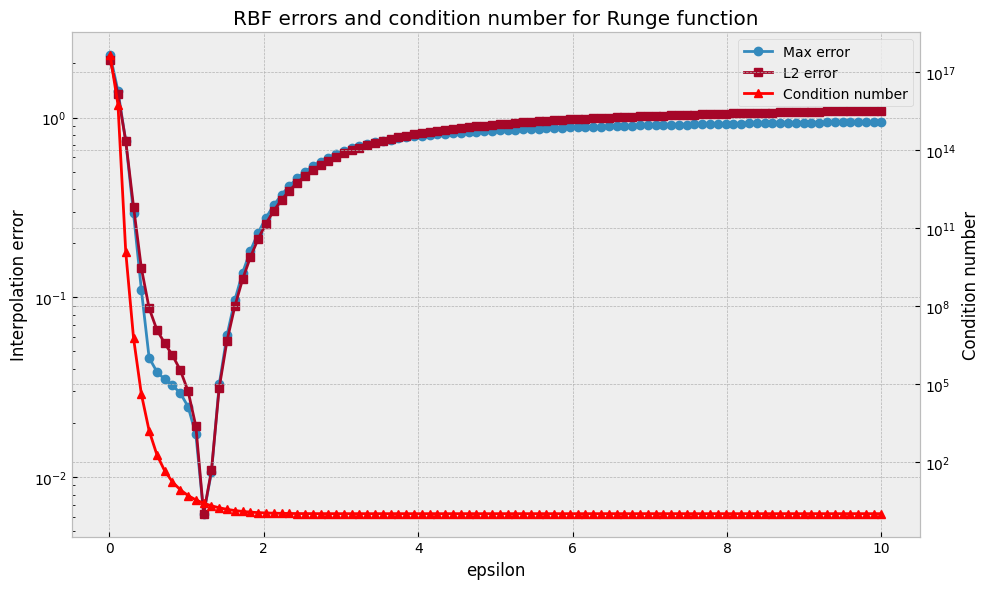

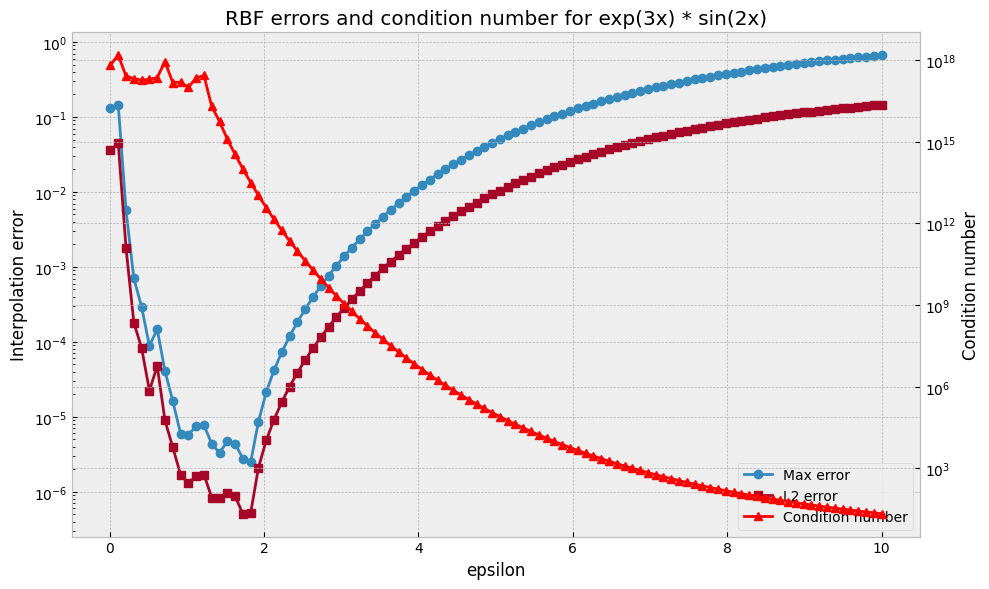

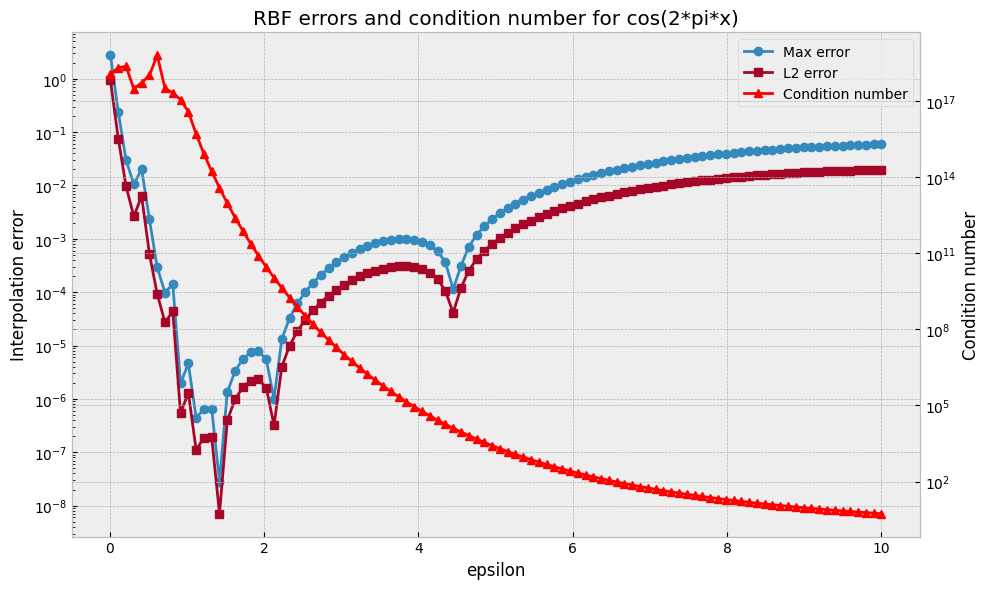

In [33]:
plot_RBF_convergence_condition(runge_torch, -5, 5, 0.01, 10.0, 100, n=10)
plot_RBF_convergence_condition(f_expsin_torch, 0, torch.pi/4, 0.01, 10.0, 100, n=10)
plot_RBF_convergence_condition(f_cos_torch,0,1, 0.01, 10.0, 100, n=10)

These plots give us quite a bit of insight, but also raises some important questions. For the last two functions we observe that for large values of $\kappa(M)$ the error of the interpolation fluctuates by several orders of magnitude. With the error only stabilizing as $\kappa(M)$ decreases. This can be interpreted as that for small values the epsilon the error is dominated by the unstable values of $w$, but as the matrix gets better conditioned with larger values of $\epsilon$ our upper bound of $\delta w$ starts having an effect and the error is instead dominated by the rapid decay of our $\phi$ function. Again we have a tradeoff between stability and precision. If we get high precision for ill-conditioned $M$, why should we care? Well as we see in the plot for the `Runge` function, we do not get good results before the condition number is low enough. We can draw parallels between the choice of epsilon values and the choice between regular interpolation and piecewise interpolation.

We wish to find an acceptable range of values of $\epsilon$. As we know; it will vary based on the chosen function and $[a,b]$. We will primarily focus on $\cos(2\pi x)$ over $[0,1]$. Of course what is accetable will vary based on why we are interpolating so this range will not work for all cases.

First we look at the stability requirement. Theorem 2.11 only bounds the relative error of the weights, $\|\delta w\|/\|w\| \leq \kappa(M)\, u$. To keep things simple we assume that the relative error of the interpolant is of the same size, i.e. that we lose roughly $\log_{10}\kappa(M)$ of the 16 significant digits. Since $|\cos(2\pi x)| \leq 1$ this gives $e \lessapprox \kappa(M)\cdot 10^{-16}$. The error rarely goes below $10^{-6}$ anyway, so we accept a rounding error of at most $10^{-5}$, which requires $\kappa(M) \leq 10^{11}$ and gives the lower bound $\epsilon \geq 2$. Note that this assumption is not guaranteed to hold, for small $\epsilon$ the weghts have to cancel eachother out, resulting in larger error. However, the plot supports it, since the error becomes erratic exactly where $\kappa(M)$ exceeds about $10^{11}$.

Now the harder part is finding an upper bound. This will vary based on the amount of interpolation points, choice of function, and purpose of interpolation, but we can reasonable require the interpolation to have less than $0.1\%$ error. This is equivalent to the error being less than $10^{-3}$, giving us an upper bound on our range with $\epsilon \leq 5$.



## <a id="task-e" name="task-e"></a>1e) Optimal node distribution with gradient descent

From our analysis of the RBF interpolation we have observed that both the distribution of nodes and $\epsilon$ have an influence on the quality of the interpolation. One could maybe derive an analytical ideal set of values, but could also use existing optimization algorithms. We have here implemented a gradiend descent algorithm with backtracking with armijo conditions with $\mathcal c = 1/2$. We have a parameter $\mathcal L$ (That can be interpreted as the Lipshictz estimate, but this is outside the scope) that we initialize and update troughout the algorithm. How this is updated is something we will look into more later in the project.

The function we try to minimize is 
$$C(\mathbf{x},\epsilon) = \frac{b-a}{N}\sum_{k=0}^{N}\Big(f(\eta_k)-\tilde{f}(\eta_k)\Big)^{2}$$

where $\tilde{f}$ is the RBF interpolation we have discussed previously.

### Implementation

In [34]:
def create_cost_function(f, a, b, N=1000):
    """
    Create a cost function for optimizing the interpolation nodes and shape parameter epsilon for RBF interpolation.
    
    Parameters:
    f (callable): The function to interpolate.
    a (float): The start of the interval.
    b (float): The end of the interval.
    N (int, optional): Number of points for the fine grid. Default is 1000.

    Returns:
    callable: The cost function C.
    """

    eta = torch.linspace(a, b, N + 1)   # fine grid, fixed
    c = f(eta)                          # data c_k = f(eta_k), fixed

    def C(z):
        # creates the RBF interpolator g for the current nodes z[:-1] and shape parameter z[-1]
        g = create_RBF_interpolator(z[:-1], f, z[-1])

        # returns the cost 
        return torch.sum((c - g(eta))**2) * (b - a) / N

    return C

def gd_backtracking(C, x, L_init=1.0, rho_inc=2.0, rho_dec=0.5, iters=100, tol=1e-12,L_reset=False):
    """
    Perform gradient descent with backtracking line search to minimize the cost function C.

    Parameters:
    C (callable): The cost function to minimize.
    x (torch.Tensor): The initial point for optimization.
    L_init (float, optional): The initial estimate of the Lipschitz constant. Default is 1.0.
    rho_inc (float, optional): The factor to increase L when the step is rejected.
    rho_dec (float, optional): The factor to decrease L when the step is accepted.
    iters (int, optional): The maximum number of iterations. Default is 100.
    tol (float, optional): The tolerance for convergence based on the norm of the gradient.
    L_reset (bool, optional): Whether to reset L to its initial value at each iteration. Default is False.

    Returns:
    tuple: A tuple containing the optimized point x, the final estimate of L, and the history of cost values.   
    """
    #NOTE: changed phi to cost to avoid confusion with the radial basis function phi

    # create a new x, that has no history and is detached from the computation graph, but requires gradients
    x = x.clone().detach().requires_grad_(True)
    history = []
    L = L_init

    for k in range(iters):
        # compute the cost and its gradient
        cost = C(x)
        g, = torch.autograd.grad(cost, x)

        # append the current cost to the history
        history.append(cost.item())

        # for testing the effect of  L, we can reset L to its initial value at each iteration
        if L_reset:
            L = L_init

        # check for convergence based on the norm of the gradient
        if g.norm() < tol:
            print(f"Converged after {k} iterations, |g| = {g.norm().item():.3e}")
            break

        # perform backtracking line search to find a suitable step size
        while True:
            # compute the new x and the model value using the current estimate of L
            with torch.no_grad(): # disable gradient tracking for the line search
                x_new = x - g / L
                d = x_new - x
                cost_new = C(x_new)
                # compute the model value using the quadratic approximation
                model = cost + g @ d + 0.5 * L * (d @ d)
            # check if the step is accepted
            if cost_new <= model:
                # update x to the new value, enable gradient tracking, and decrease L for the next iteration
                x = x_new.requires_grad_(True)
                L *= rho_dec

                break
            # if the step is rejected, increase L and try again
            L *= rho_inc

    return x.detach(), L, history


def optimize_nodes(f, a, b, epsilon, n, L=[1.0], iters=200,
                   N=5000, plot=True,rho_inc=2.0, rho_dec=0.5, L_reset=False):
    """
    Optimize the interpolation nodes and shape parameter epsilon for RBF interpolation using gradient descent with backtracking line search.

    Parameters:
    f (callable): The function to interpolate.
    a (float): The start of the interval.
    b (float): The end of the interval.
    epsilon (float): The initial shape parameter for the radial basis function.
    n (int): The number of intervals.
    L (list, optional): A list of initial estimates of the Lipschitz constant for backtracking line search. Default is [1.0].
    iters (int, optional): The maximum number of iterations for gradient descent. Default is 200.
    N (int, optional): Number of points for the fine grid. Default is 5000.
    plot (bool, optional): Whether to plot the results. Default is True.
    rho_inc (float, optional): The factor to increase L when the step is rejected. Default is 2.0.
    rho_dec (float, optional): The factor to decrease L when the step is accepted. Default is 0.5.
    L_reset (bool, optional): Whether to reset L to its initial value at each iteration. Default is False.

    Returns:
    list: A list of tuples containing the optimized nodes, optimized epsilon, initial cost, final cost, and history of cost values for each initial L.
    """

    # create the cost function for the given function f and interval [a, b]
    C = create_cost_function(f, a, b, N)

    # create the initial nodes and shape parameter for RBF interpolation
    x0 = torch.linspace(a, b, n + 1)
    z0 = torch.cat([x0, torch.tensor([float(epsilon)])]) # concatenate the nodes and epsilon into a single tensor for optimization
    cost0 = C(z0).item()

    # list to store the results for each initial L
    results = []

    # loop over each initial L value and perform gradient descent with backtracking line search
    for initial_L in L:
        # perform gradient descent with backtracking line search to optimize the nodes and shape parameter
        z_opt, _, history = gd_backtracking(
            C, z0, L_init=initial_L, iters=iters, rho_inc=rho_inc, rho_dec=rho_dec, L_reset=L_reset
        )

        # get the optimized nodes and shape parameter from the optimized tensor
        x_opt = z_opt[:-1]
        eps_opt = z_opt[-1].item()

        # compute the final cost after optimization
        cost1 = C(z_opt).item()

        # print the results for the current initial L value
        print(
            f"L={initial_L}: cost {cost0:.3e} -> {cost1:.3e}, "
            f"eps: {epsilon} -> {eps_opt:.4f}"
        )

        # append the results for the current initial L value to the results list
        results.append(
            (x_opt, eps_opt, cost0, cost1, history)
        )

    if plot:
        x_plot = torch.linspace(a, b, N)
        f_plot = f(x_plot).numpy()

        fig, axes = plt.subplots(
            2, len(L),
            figsize=(6 * len(L), 9),
            squeeze=False
        )

        for column, (initial_L, result) in enumerate(zip(L, results)):
            x_opt, eps_opt, _, _, history = result

            ax_interp = axes[0, column]
            ax_conv = axes[1, column]

            g0 = create_RBF_interpolator(x0, f, epsilon)
            g1 = create_RBF_interpolator(x_opt, f, eps_opt)

            ax_interp.plot(
                x_plot.numpy(), f_plot,
                "k", label=f.__name__
            )
            ax_interp.plot(
                x_plot.numpy(), g0(x_plot).numpy(),
                "--", label="start"
            )
            ax_interp.plot(
                x_plot.numpy(), g1(x_plot).numpy(),
                label="optimised"
            )
            ax_interp.scatter(
                x0.numpy(), f(x0).numpy(),
                marker="x", label="start nodes"
            )
            ax_interp.scatter(
                x_opt.numpy(), f(x_opt).numpy(),
                color="red", label="optimised nodes"
            )

            ax_interp.set_title(f"L={initial_L}, interpolation")
            ax_interp.set_xlabel("x")
            ax_interp.set_ylabel("f(x)")
            ax_interp.grid()
            ax_interp.legend()

            ax_conv.semilogy(
                range(1, len(history) + 1),
                history
            )
            ax_conv.set_title(f"L={initial_L}, convergence")
            ax_conv.set_xlabel("iteration")
            ax_conv.set_ylabel("C")
            ax_conv.grid()

        fig.tight_layout()
        plt.show()

    return results

def check_gradient(f, a, b, epsilon, n, N=5000):
    """
    Check for NaN values in the gradient of the cost function for RBF interpolation.

    Parameters:
    f (callable): The function to interpolate.
    a (float): The start of the interval.
    b (float): The end of the interval.
    epsilon (float): The shape parameter for the radial basis function.
    n (int): The number of intervals.
    N (int, optional): Number of points for the fine grid. Default is 5000.
    """
    C = create_cost_function(f, a, b, N)
    z0 = torch.cat([torch.linspace(a, b, n + 1), torch.tensor([float(epsilon)])])
    z0.requires_grad_(True)
    g, = torch.autograd.grad(C(z0), z0)
    print(f"{f.__name__}: NaN in gradient: {torch.isnan(g).any().item()}")


### Gradient NaN check

In [35]:
check_gradient(runge_torch, -5.0, 5.0, 2.0, 10)
check_gradient(f_cos_torch, 0.0, 1.0, 1.0, 10)
check_gradient(f_expsin_torch, 0.0, torch.pi / 4, 2.0, 10)

Runge function: NaN in gradient: False
cos(2*pi*x): NaN in gradient: False
exp(3x) * sin(2x): NaN in gradient: False


Before we start we do a check that the autograd function has not silently created any NaN values in the gradient. As we can see, none were found. This is because we avoid using $|.|$.

### Runge function: initial L and scaling parameters ρ

L=1: cost 5.984e-02 -> 3.182e-06, eps: 2.0 -> 1.3016
L=10: cost 5.984e-02 -> 3.572e-05, eps: 2.0 -> 1.3673
L=100: cost 5.984e-02 -> 1.114e-03, eps: 2.0 -> 1.5763


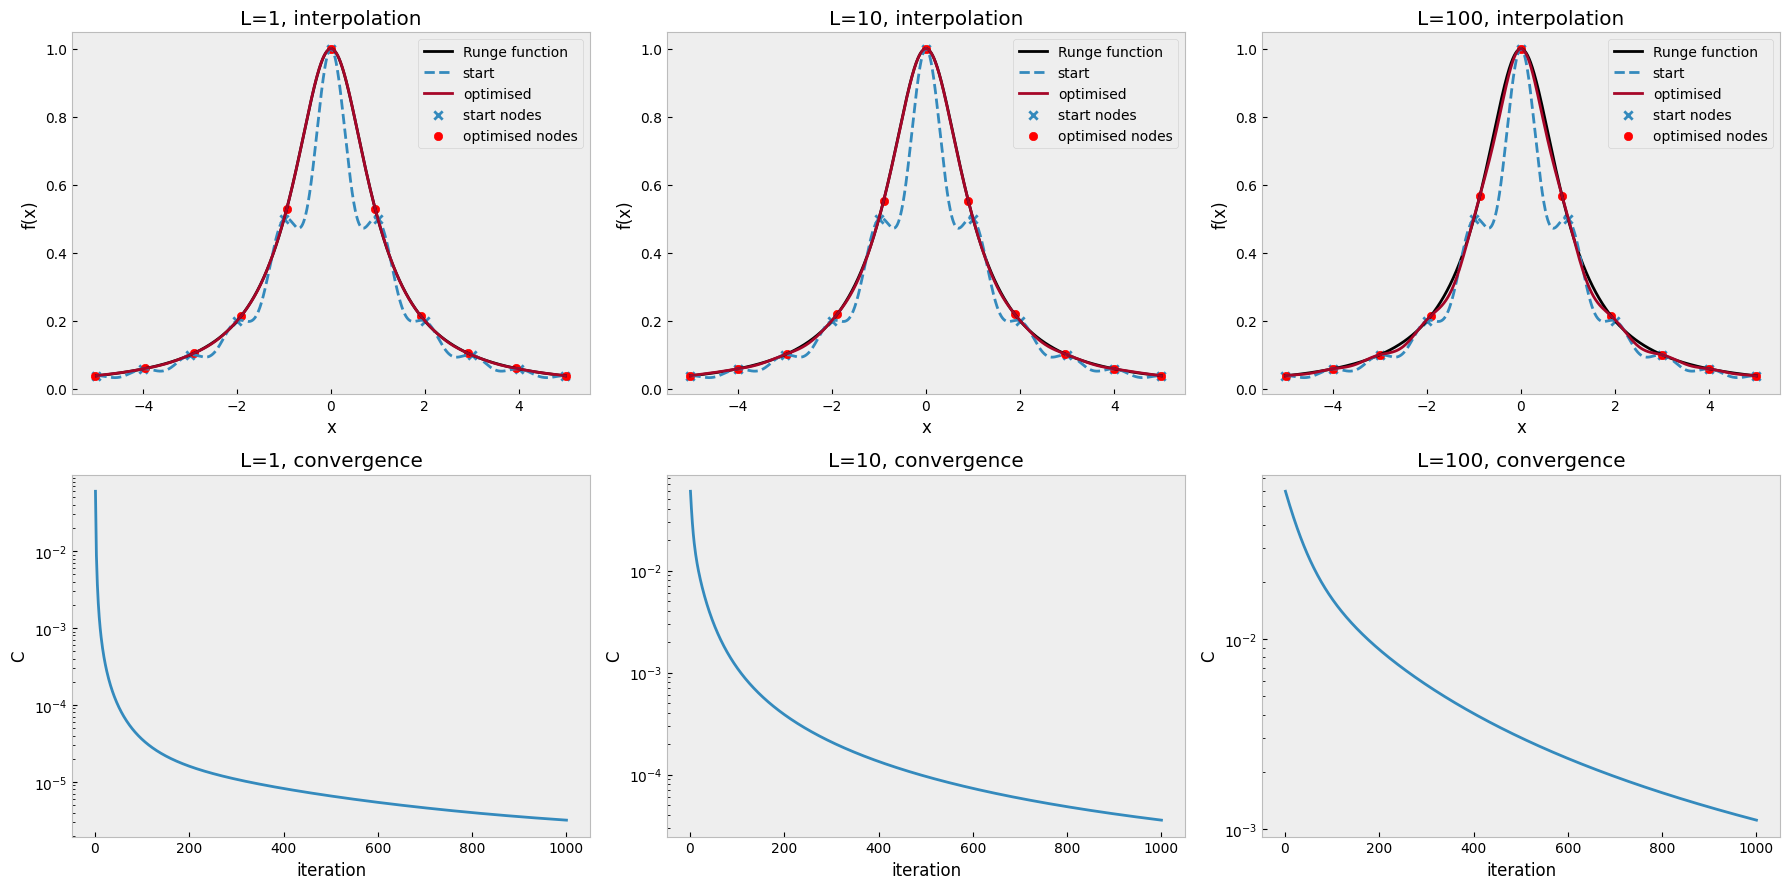

In [36]:
result = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    L_reset=True
)

When intitializing with $\epsilon = 2$ and equidistant nodes, we see that for every choice of $\mathcal L$ the algorithm seems to find a better set of interpolation values. For higher $\mathcal L$ the algorithm takes a longer time to converge. For longer values of $\mathcal L$ it takes too short steps. In this method we reset $\mathcal L$ to the intial value after each step. It could be advantageus to scale the $\mathcal L $-value when accepting a step. In the next plot we try this.

L=1: cost 5.984e-02 -> 1.920e-06, eps: 2.0 -> 1.2900
L=10: cost 5.984e-02 -> 1.906e-06, eps: 2.0 -> 1.2895
L=100: cost 5.984e-02 -> 1.905e-06, eps: 2.0 -> 1.2894


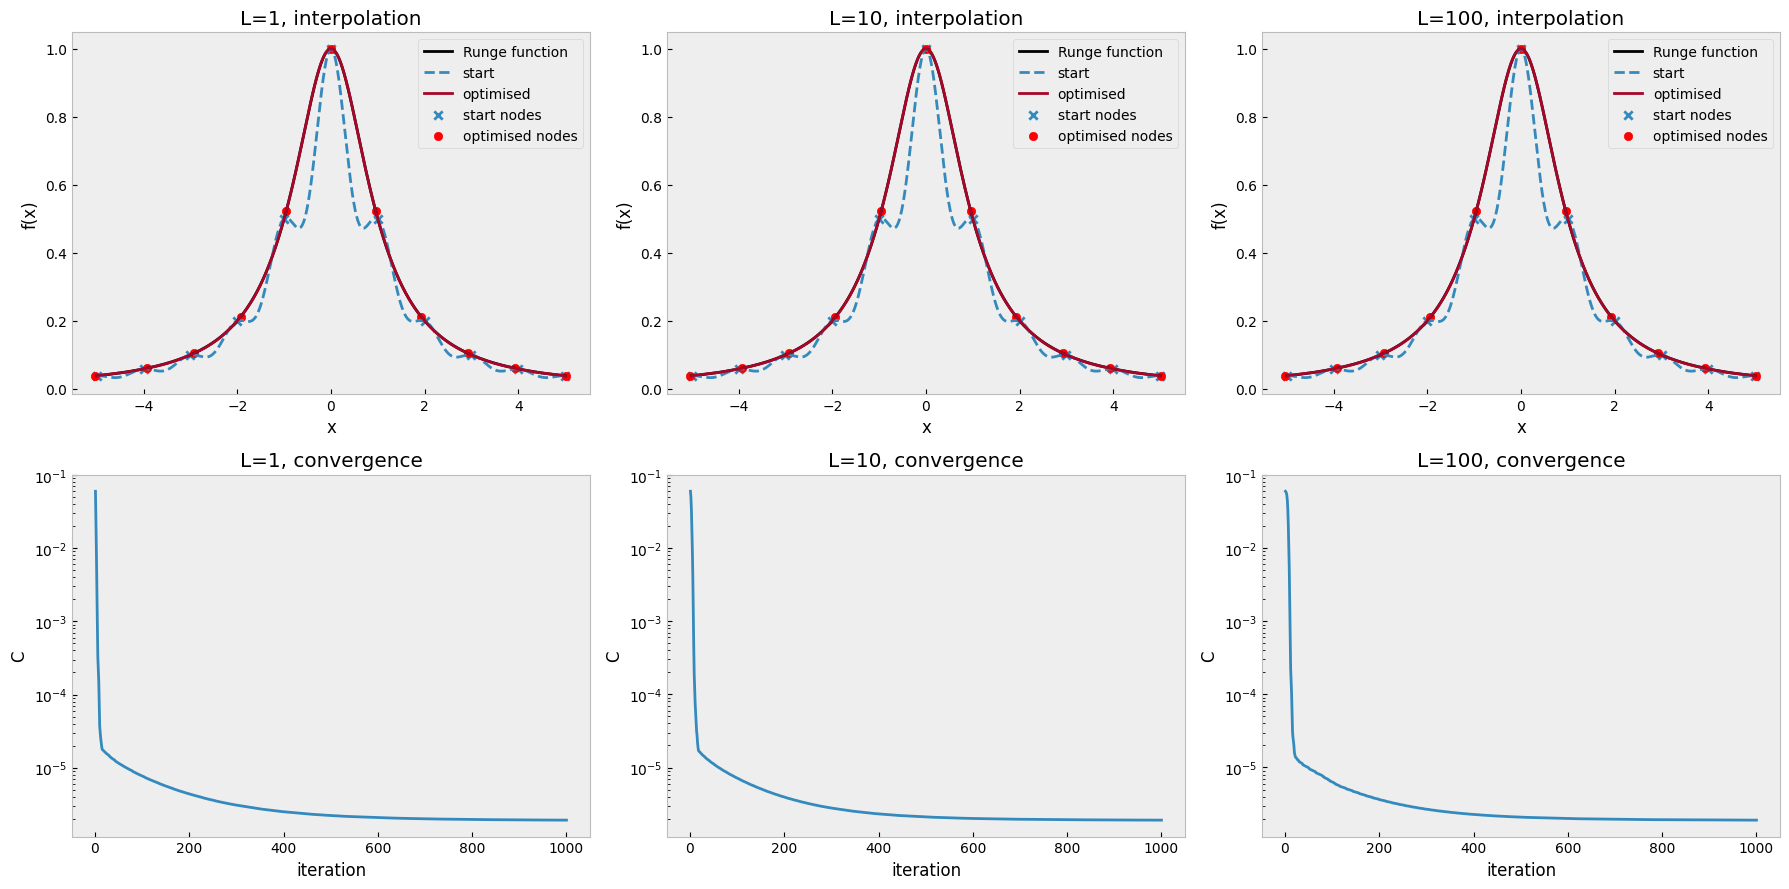

In [37]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000
)

Not only does it not seem to be a diffrence inbetween the initial values of $\mathcal L$, but the algorithm also converges faster. This is due to our scaling parameters $\bar \rho >1 \text{ and } \underline \rho < 1$ that respectivly decrease and increase $\mathcal L$ when a step is accepted or rejected. So far we have used $\bar \rho = 2\text{ and } \underline \rho = 0.5$ , but let us try to change to $\bar \rho = 1.01\text{ and } \underline \rho = 0.99$. Now the algorithm does less scaling.

L=1: cost 5.984e-02 -> 1.959e-06, eps: 2.0 -> 1.2911
L=10: cost 5.984e-02 -> 2.037e-06, eps: 2.0 -> 1.2928
L=100: cost 5.984e-02 -> 2.338e-06, eps: 2.0 -> 1.2964


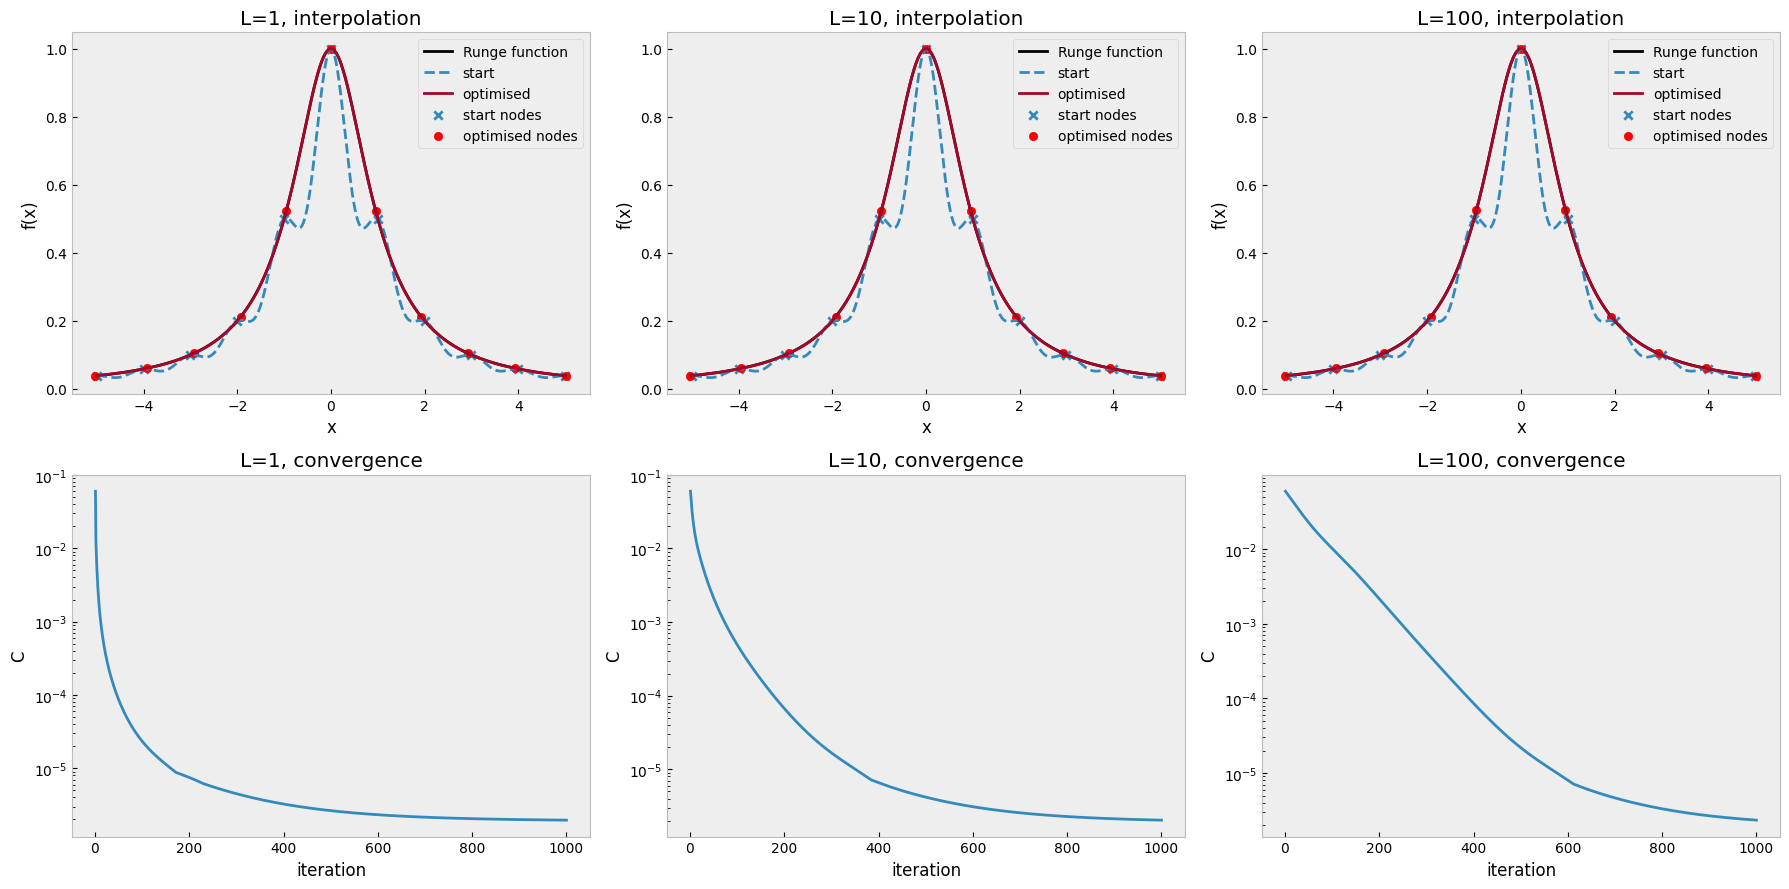

In [38]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    rho_dec=0.99,
    rho_inc=1.01
)

The same pattern emerges, if we pick too low values for $\bar \rho \text{ and } \underline \rho$ we will loose the speed that comes from the scaling. But what if we instead took a greedier choice with $\bar \rho = 100 \text{ and } \underline \rho = 0.01$. This is obviously extreme, but is chosen so that the pattern is visible on the plot.

L=1: cost 5.984e-02 -> 1.889e-06, eps: 2.0 -> 1.2884
L=10: cost 5.984e-02 -> 5.399e-06, eps: 2.0 -> 1.3092
L=100: cost 5.984e-02 -> 1.889e-06, eps: 2.0 -> 1.2884


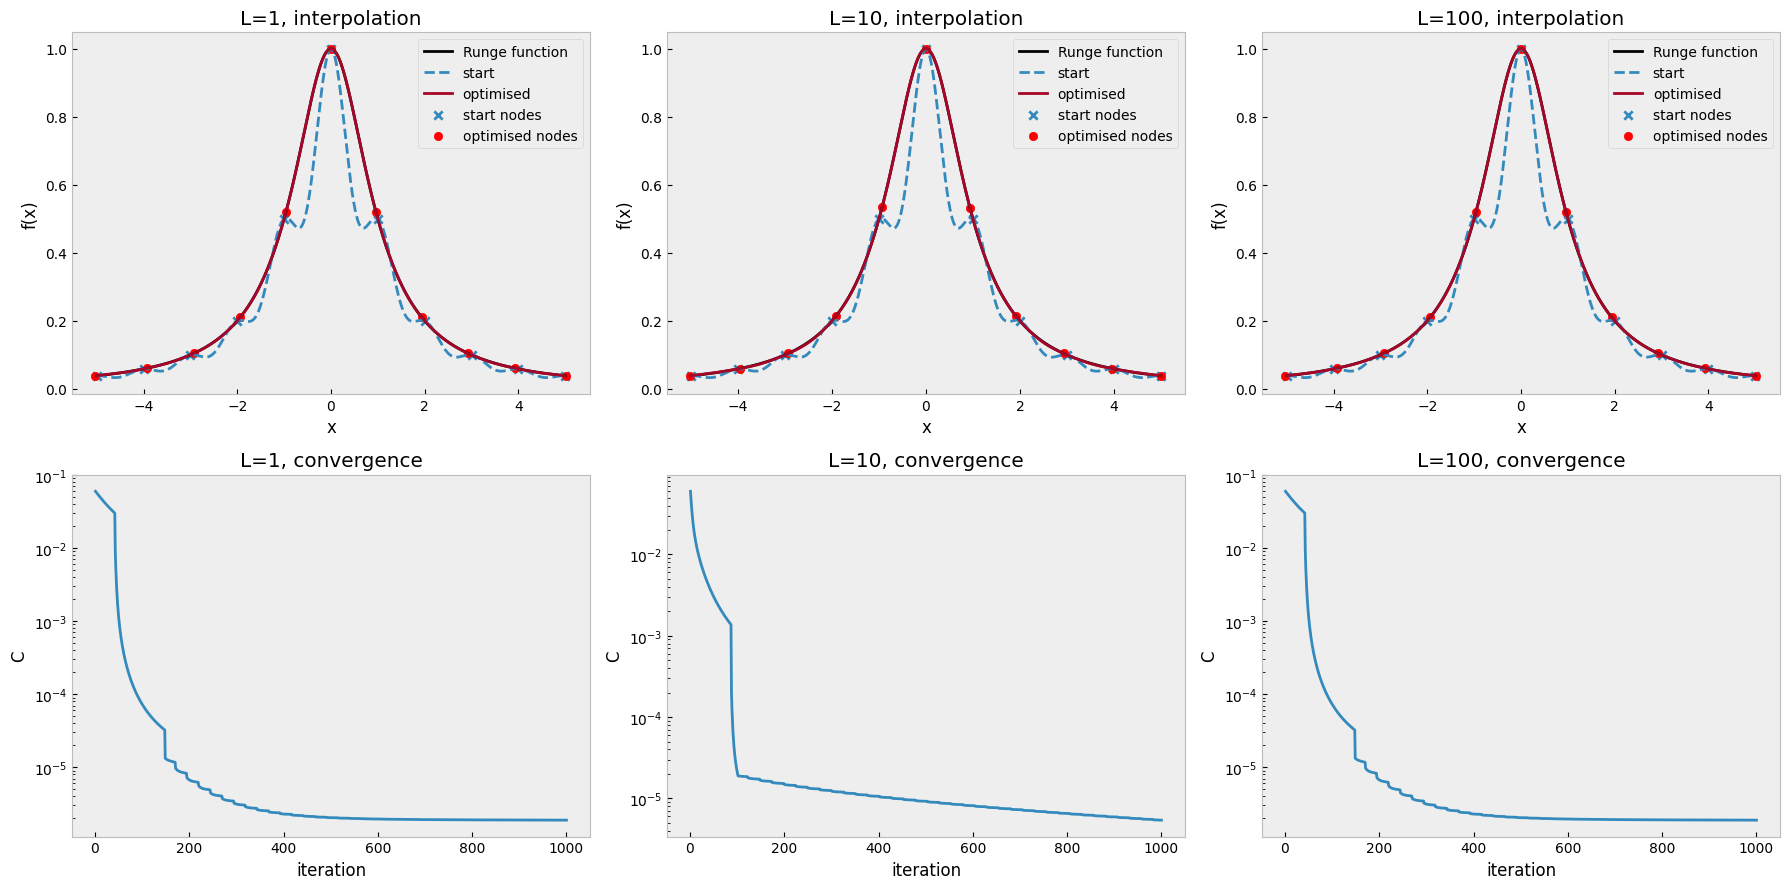

In [39]:
result = results = optimize_nodes(
    runge_torch,
    -5.0,
    5.0,
    epsilon=2.0,
    n=10,
    L=[1, 10, 100],
    iters=1000,
    rho_dec=0.01,
    rho_inc=100
)

Our system still converges, but the convergence is more jagged. It consistenly under and overshoots, making the algorithm more unstable. So we can not be too greedy in our choice of parameters. We may not need to be as precise when it comes to choosing $\epsilon$, but we need to choose acceptable values for $\bar \rho \text{ and } \underline \rho$.

### cos(2πx): local minima

So far we have focused on the `Runge` function for the optimalization. What if we look at $\cos(2\pi x)$? Will the method also work here?

Converged after 2 iterations, |g| = 9.221e-13
L=1.0: cost 1.361e-11 -> 1.826e-13, eps: 1 -> 1.0000


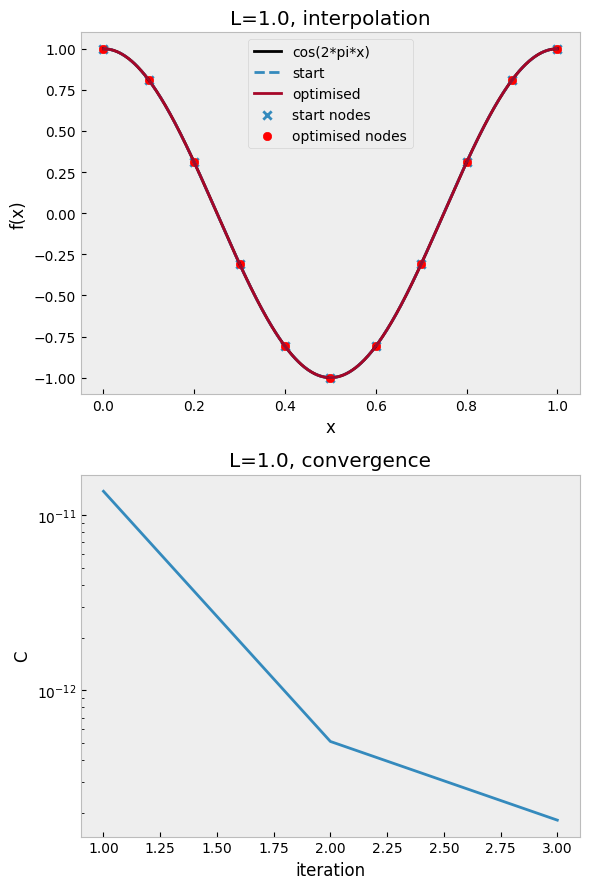

In [40]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=1, n=10,iters=1000)

The algorithm converges after only 3 iterations. If the size of the gradient is less than $10^{-12}$ we stop the algorithm. The change is just to small to matter. Our cost function that we minimize is not necessarily a convex function, so we are not guaranteed a single ideal case. Showing this is outside the scope of the project, but we can theorize that the start case we have given it is in a local valley. To show this we change intital $\epsilon$ to $4$.

L=1.0: cost 8.023e-08 -> 5.838e-10, eps: 4 -> 4.5240


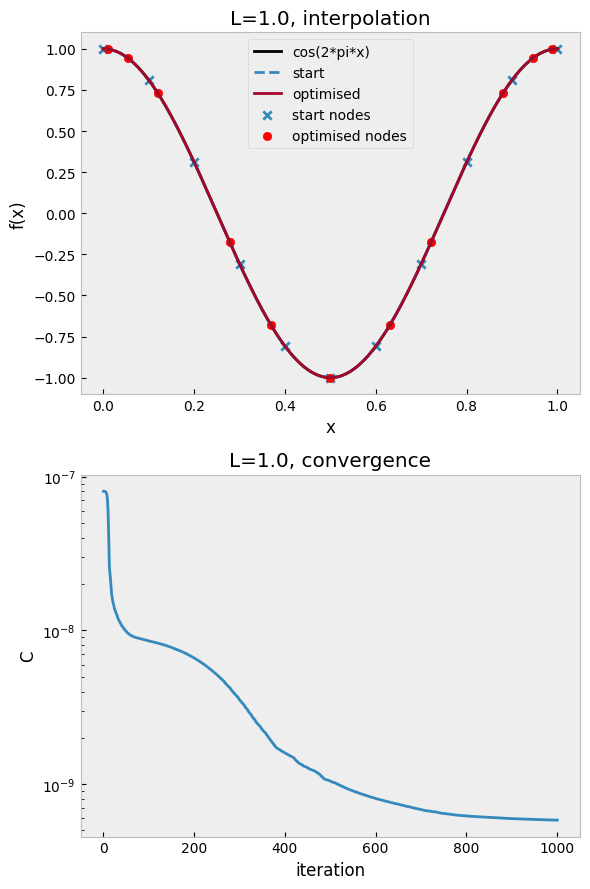

In [41]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=4, n=10,iters=1000)

Here we do not see the same pattern as before. The speed of convergence is not constant. It seems that the algorithm hits a flat spot that it gets over after $100$ iterations. It could be that the algorithm quits on a flat spot, if we increased the max number of iterations maybe another dip in the cost function is found? We increase to $10,000$ iterations

Converged after 7997 iterations, |g| = 9.897e-13
L=1.0: cost 8.023e-08 -> 5.527e-10, eps: 4 -> 4.5588


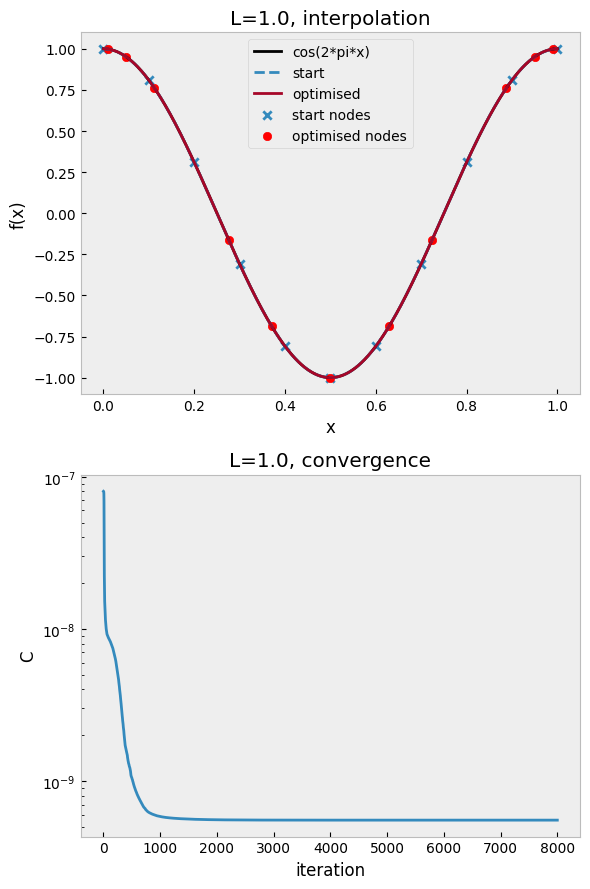

In [42]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=4, n=10,iters=10000)

The answer is in this case; no. Supporting the valley theory that we will introduce now.

The algorithm increases $\epsilon$ instead, even tough we know that for $\epsilon = 1$ the interpolation is almost perfect. This can be due to 2 different explanations. 1) We know that for smaller values of $\epsilon$ our $M$ matrix becomes ill-conditioned. This could possibly make the gradient unstable and make the algorithm worse. This could also contribute to the quick convergence with $\epsilon =1$. Or 2) this initial value is in another local valley. This is hard to visualize since it will be a $12$-dimensional valley, but we can try by looking at the $1$-dimensional case we have discussed before where we only changed the $\epsilon$ values. We plot again for readability.

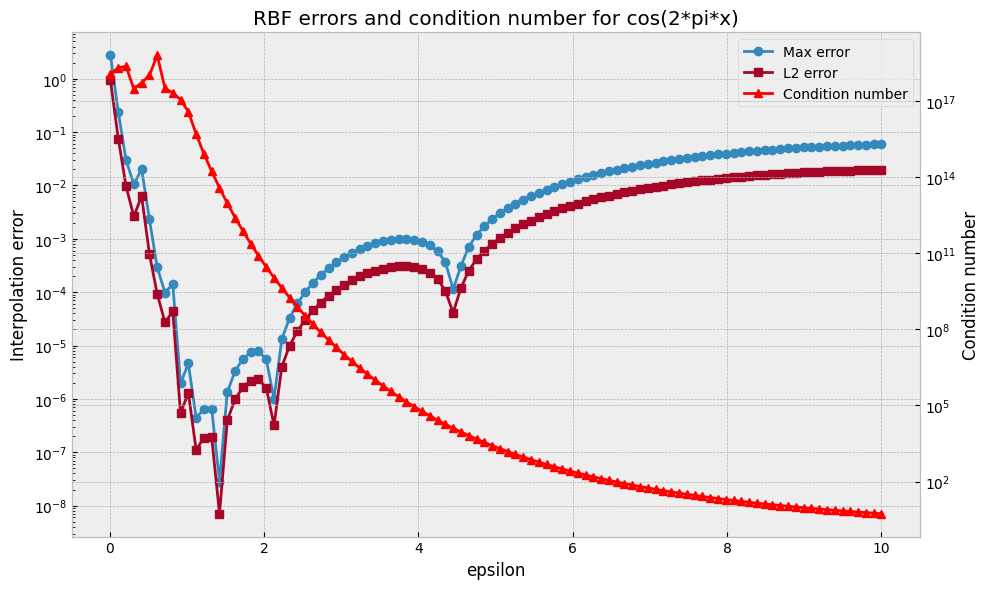

In [43]:
plot_RBF_convergence_condition(f_cos_torch,0,1, 0.01, 10.0, 100, n=10)

This is not entirely accurate, but we se that $\epsilon = 4$ is inside its own valley. $\epsilon$ converges to $4.5240$, which seems to be the same value for epsilon that is inside the valley we see. This highlights a limitation of the algorithm, it can converge to local valleys, not guaranteeing a global optimizer. 

While we are on this we can try choosing $\epsilon = 0.1$ to test what happens when we are inside the ill conditioned area.

L=1.0: cost 1.731e-02 -> 4.103e-03, eps: 0.1 -> 0.1000


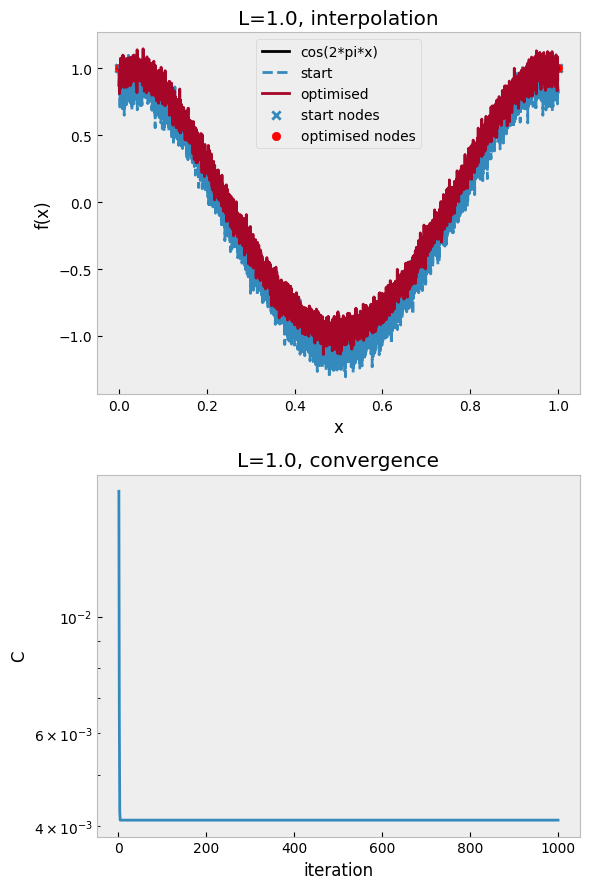

In [44]:
result = optimize_nodes(f_cos_torch, 0, 1.0, epsilon=0.1, n=10,iters=1000)

Now the algorithm also converges, but does not stop. I seems to get stuck somewhere. It could be that the ill-conditioned matrix creates a small local valley that it can not escape. Or that the gradient approximation we do becomes garbage? This is most likely outside the scope of this project, but again highlights the consequences of an ill-conditioned matrix.

### exp(3x)·sin(2x)

We wish to further look at the valley principle. Our last function $e^{3x}\sin(2x)$ did not have the same oscilation effect for choice of $\epsilon$. It could be that we do not get into the same valley effect we found for the $\cos$ function. To start with we plot for just a regular estimate for $\epsilon$.

L=1.0: cost 1.555e-11 -> 1.554e-11, eps: 2.0 -> 2.0000


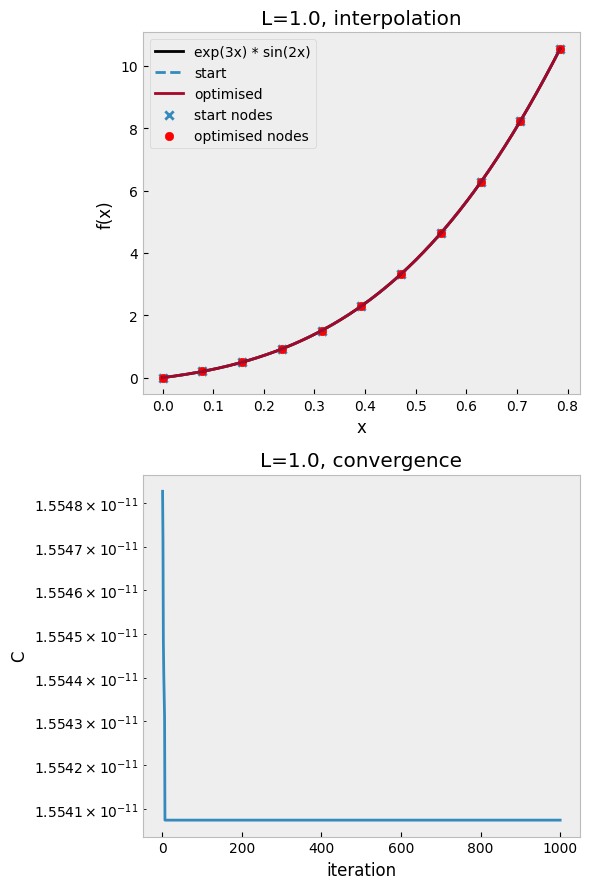

In [45]:
result = optimize_nodes(f_expsin_torch, 0, torch.pi/4, epsilon=2.0, n=10,iters=1000)

We again see the same effect where the initial guess is so good that the algorithm can not find a better one. But what if we start with $\epsilon = 4$? Will we again see the valley effect? We plot the error of $\epsilon$ agin for readability.

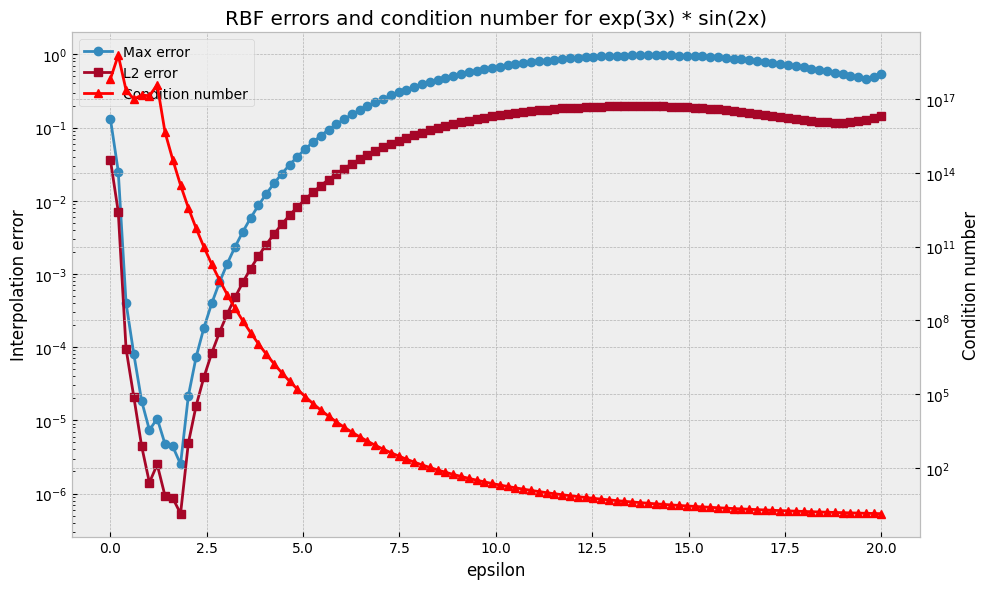

In [46]:
plot_RBF_convergence_condition(f_expsin_torch, 0, torch.pi/4, 0.01, 20.0, 100, n=10)


Converged after 727 iterations, |g| = 7.549e-13
L=1.0: cost 5.378e-06 -> 1.214e-14, eps: 4.0 -> 1.8222


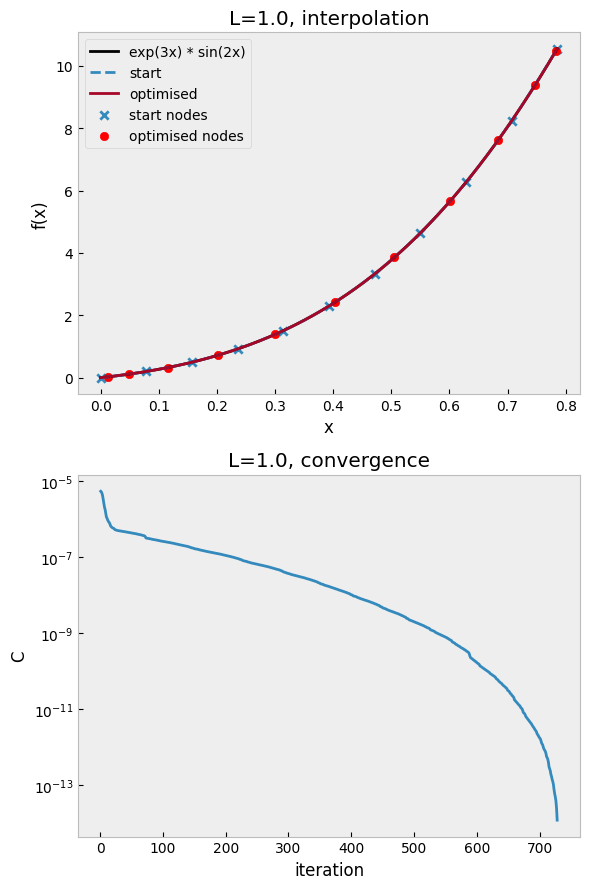

In [47]:
result = optimize_nodes(f_expsin_torch, 0, torch.pi/4, epsilon=4.0, n=10,iters=1000)


The algoritm quickly finds the main valley and converges. So it is important to take this into consideration when choosing an initial value. But this value for $\epsilon$ is on the steep part of the graph. What if we picked a a value that has a smaller slope. Say $\epsilon = 10 $. Will we still get to our ideal condition?

L=1.0: cost 2.107e-02 -> 8.235e-04, eps: 10 -> 10.0058


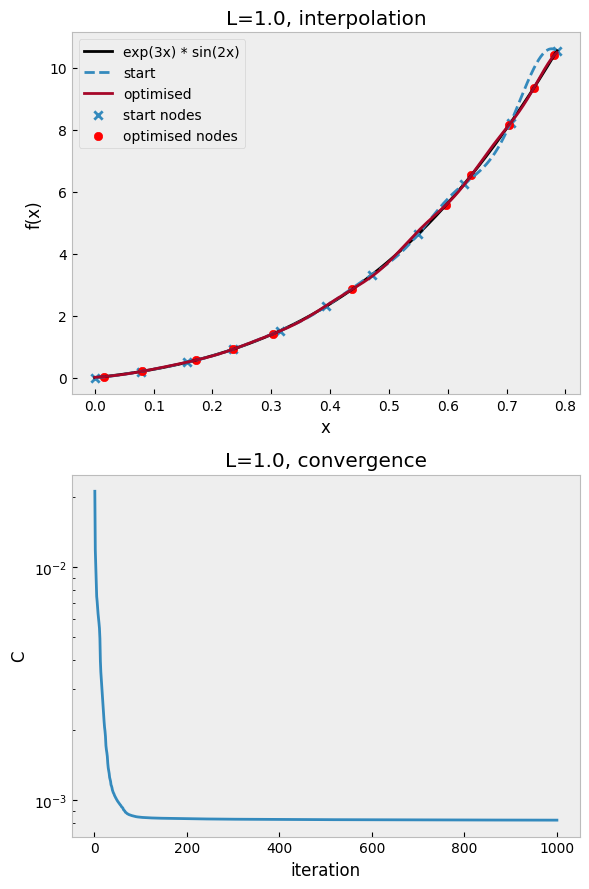

L=1.0: cost 2.107e-02 -> 7.927e-04, eps: 10 -> 10.1112


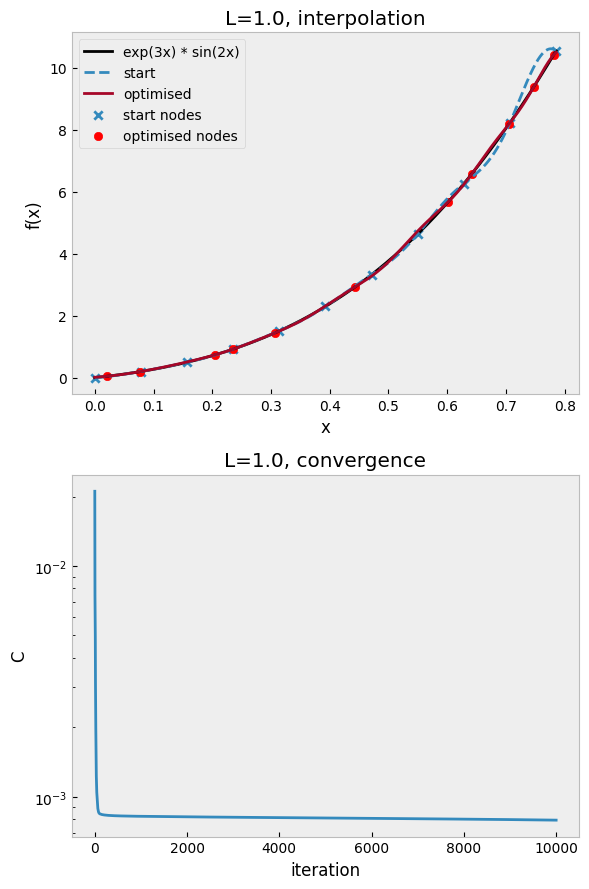

In [48]:
result = optimize_nodes(f_expsin_torch, 0, torch.pi/4, epsilon=10, n=10,iters=1000)
result = optimize_nodes(f_expsin_torch, 0, torch.pi/4, epsilon=10, n=10,iters=10000)

The answer is no. It seems to get stuck on the flat part of the slope. Our main theory is that this is due to the parameter $\mathcal L$ dictating how big of a step we can take on both $x$ and $\epsilon$. When starting on a flat part the epsilon will do very small steps due to the gradient being so small. In the mean time the nodes will find their ideal distribution and settle for this. After finding the ideal node distribution the algorithm will only accept steps that have enough improvement. Moving too far away with the nodes will give a worse solution, so large steps are not accepted. Since the gradient for $\epsilon$ is so small it will never actually move in any meaningfull way. A fix for this could be to introduce seperate parameters for the nodes and $\epsilon$, but this is moving too far outside what we consider the scope of the project.

### Comparison with Lagrange interpolation for increasing n

Now that we have discussed the limitations of our gradient descent for a fixed number of interpolation nodes. Let us start seeing what happens when we change the number of nodes, and how the method compares to the regular interpolation methods we discussed in the start of the project. We will only consider $\cos(2\pi x)$ on $[0,1]$. We assume that choice of $\mathcal L$ will not matter due to sufficient scaling parameters. We wish to avoid the issues with getting stuck in non-ideal valleys or flat spots. When adding more nodes the space between the nodes get smaller and therefore a higher shape parameter is necessary. We therefore scale $\epsilon$ by the number of nodes $\epsilon(n) = 2n/10$.

In [49]:
def compare_interpolators(n_vals, epsilon, N=1000):
    """
    Compare the interpolation errors of different interpolation methods.

    Parameters:
    n_vals (list): List of the number of interpolation points.
    epsilon (float): The tolerance for the interpolation error.
    N (int): The number of test points to use for computing the error.

    Returns:
    pandas.DataFrame: A DataFrame containing the comparison results.
    """

    # define the interval for interpolation
    a = 0.0
    b = 1.0

    # define the functions to interpolate, one for torch and one for numpy, since the original functions were not compatible with torch tensors
    f1 = f_cos_torch
    f2 = f_cos

    # lists to store the errors for each interpolation method
    results_opt = []
    results_cheb = []
    results_equi = []

    # loop over the number of interpolation points and compute the errors for each method
    for n in n_vals:
        # create the interpolants for each method
        lagrange_cheb = make_lagrange(f2, a, b, n, nodes="chebyshev")
        lagrange_equi = make_lagrange(f2, a, b, n, nodes="equidistant")
        RBF_opt_result = optimize_nodes(f1, a, b, epsilon*n/10, n, iters=1000, plot=False)[0]
        RBF_opt_nodes = RBF_opt_result[0]
        RBF_opt_eps = RBF_opt_result[1]
        RBF_opt = create_RBF_interpolator(RBF_opt_nodes, f1, RBF_opt_eps, interval=(a, b))  

        # compute the errors for each interpolant and append them to the respective lists
        results_cheb.append(error(lagrange_cheb))
        results_equi.append(error(lagrange_equi))
        results_opt.append(error_torch(RBF_opt))   

    # create a pandas DataFrame to store the results
    results_df = pd.DataFrame({
        "n": n_vals,

        "Lagrange Chebyshev L2 Error": [res[1] for res in results_cheb],

        "Lagrange Equidistant L2 Error": [res[1] for res in results_equi],

        "RBF Optimized L2 Error": [res[1] for res in results_opt]
    })

    # make it look nice for display in a jupyter notebook
    styled_table = (
        results_df.style
        .format({
            "Lagrange Chebyshev L2 Error": "{:.3e}",
            "Lagrange Equidistant L2 Error": "{:.3e}",
            "RBF Optimized L2 Error": "{:.3e}",
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-weight", "bold"), ("font-size", "14pt")]},
            {"selector": "td", "props": [("font-size", "13pt")]},
        ])
    )

    return styled_table

In [50]:
result =compare_interpolators([2,5,7,10,15,20,30,40,50,70,100],2)
display(result)

L=1.0: cost 1.463e-01 -> 9.115e-05, eps: 0.4 -> 2.2397
L=1.0: cost 1.571e-04 -> 1.522e-08, eps: 1.0 -> 1.4397
L=1.0: cost 5.736e-08 -> 2.562e-12, eps: 1.4 -> 1.1126
L=1.0: cost 3.708e-12 -> 3.708e-12, eps: 2.0 -> 2.0000
L=1.0: cost 1.688e-12 -> 1.687e-12, eps: 3.0 -> 3.0000
L=1.0: cost 6.667e-14 -> 1.906e-14, eps: 4.0 -> 4.0000
Converged after 0 iterations, |g| = 7.123e-13
L=1.0: cost 3.704e-15 -> 3.704e-15, eps: 6.0 -> 6.0000
Converged after 0 iterations, |g| = 1.899e-13
L=1.0: cost 7.300e-16 -> 7.300e-16, eps: 8.0 -> 8.0000
Converged after 1 iterations, |g| = 6.536e-13
L=1.0: cost 2.778e-15 -> 1.968e-15, eps: 10.0 -> 10.0000
L=1.0: cost 8.862e-15 -> 1.107e-15, eps: 14.0 -> 14.0000
L=1.0: cost 4.385e-15 -> 3.041e-15, eps: 20.0 -> 20.0000


,n,Lagrange Chebyshev L2 Error,Lagrange Equidistant L2 Error,RBF Optimized L2 Error
0,2,2.604e-01,3.944e-01,9.727e-03
1,5,2.121e-02,2.925e-02,1.248e-04
2,7,1.003e-03,1.871e-03,1.618e-06
3,10,6.404e-07,3.822e-06,1.925e-06
4,15,8.070e-11,1.191e-09,1.299e-06
5,20,3.864e-16,2.204e-13,1.380e-07
6,30,4.212e-16,1.034e-10,6.085e-08
7,40,6.133e-16,8.928e-08,2.702e-08
8,50,6.395e-16,5.953e-05,4.436e-08
9,70,7.322e-16,3.814e+01,3.328e-08


Regular interpolation behaves as we expect. Converges for `Chebyshev` nodes but blow up for `equidistant` nodes. This is already discussed in detail, so we instead discuss the optimized RBF interpolation.

An obvious limitation of the optimized RBF interpolation we quicly notice is that since the cost function is the square of the $L_2$-norm it puts a quasi-lower bound on the precision of the interpolation. Once we get the cost function down to machine precision the algorithm will of course stall. Meaning that we rarely get results better than $10^{-8}$ since it is the square root of machine precision. This also makes the changes in $\epsilon$ smaller as we increase $n$ due to it not being able to optimize something that is dominated by machine error. 

There may be a stricter limitation on the precision, but the method still gives consistently good results. It may not converge as quick as regular interpolation, but does not seem to blow up the way Lagrange interpolation with `equidistant` nodes does.

Where the method seems to be best when the number of nodes are few. Here the method has not yet reached its lower bound on precision and is able to find a set of nodes and value for $\epsilon$ so that the interpolation is better. This can be usefull in cases where you wish to create a quick interpolation that will be repetadly used and needs to have a low runtime but not necessarily precise down to machine precision.

A small detail to notice is that the algorithm may get stuck on a non ideal solution. For $n = 10,15$

## <a id="task-f" name="task-f"></a>1f) Optimal nodes for polynomial interpolation

What if we try to minimize a similar cost function? Where we use polynomial interpolation instead. Let us define this new cost function.
$$C(\mathbf{x}) = \frac{b-a}{N}\sum_{k=0}^{N}\Big(f(\eta_k)-p_n(\eta_k)\Big)^{2}, \quad p_n(\eta) = \sum_{i=0}^n \ell_i (\eta)f(x_i)$$
Where
$$ \ell_i(\eta) = \prod_{j=0,j\neq i}^n \dfrac{\eta-x_j}{x_i-x_j}$$


First thing to notice is that $C(\mathbb x)$ is a quadrature approximation of $\|f-p_n\|_2^2$. So we assume that we try minimizing this norm function instead. We assume that $f\in C[a,b]\subset L_2[a,b]$, which allows us to utilize the inner product that defines the norm in this Hilbert space and the intermediate value theorem. One can relax the minimization problem by removing the interpolation condition and instead minimzing the norm over all functions. $p^* \in \Pi_n[a,b] = \{ f\in L_2[a,b] \: | \: \exists (a_i) \in \mathbb{R}^{n+1} s.t. f(x) = \sum_{i=0}^n a_i x^i  \}$ so that $||p^*-f|| = \min_{ q \in \Pi_n[a,b]}||q-f||$. From Theorem 9.2 in [BOK p.264] we know that $p^*$ exists and is unique. So the question is, how good can we make $p_n$ compared to the ideal solution $p^*$? Our goal is to show that $\exists \mathbf x \in [a,b]^{n+1} \text{ s.t. } p_n = p^*$.

It is trivial to show that $\Pi_n[a,b] $ is a $(n+1)$-dimensional subspace of $L_2[a,b]$. Using this we can create the the minimal polynomial requirement by use of the best approximation theorem for inner product spaces. $\langle f-p^*,q \rangle = 0\: \forall\: q \in \Pi_n[a,b]$. This is a common theorem that is known from most introductory linear algebra classes, so we will not be showing it. Let $\mathcal{I}_f$ be the set of all interpolation polynomials possible. We only need to show that $p^* \in \mathcal{I}_f$ and then find the nodes corresponding to the solution.

Start by defining $e = f-p^*$. Assume that $e$ is $0$ at $m < n+1$ points, by the intermediate value theorem $e$ switches sign at $k\leq m$ points. Call these points $\{t_i \}_{i=1}^k \subset [a,b] \text{ s.t. } t_1 < t_2 < \dots < t_k$. Construct a new polynomial $q(x) = 1\cdot \prod_{i=1}^k (x-t_i)$. These two functions change sign at the same time, resulting in $e(x)\cdot q(x)$ having constant sign over $x\in [a,b]$. Since $q \in \Pi_n[a,b]$ then $\langle e,q\rangle = \int_a^b e(x)q(x) dx = 0$. Since $e(x)q(x)$ has constant sign then $e=0$, breaking with our original assumption that $e$ is only zero at a finite set of points less than $n+1$. 

From this we know that $\exists \mathbf x \in [a,b]^{n+1}\text{ s.t. } x_j \neq x_i \text { when } i\neq j \text{ and } e(x_j) = 0 \Leftrightarrow f(x_j) = p^*(x_j)$. Therefore we can create $\{\ell_j\}_{j=0}^n$ and $p_n$ from these nodes. Since $p_n(x_j) - p^*(x_j)= 0$ for $j = 0,1,\dots , n$ and $p_n - p^* \in \Pi_n[a,b] $ then $p_n = p^*$. Meaning that the best interpolation in $L_2$-norm is also the best polynomial approximation in $L_2$-norm.

But is minimizing the cost function using gradient descent the best way to find $p_n$? Since we know that the best approximation is also an interpolation polynomial could it be easier to instead calculate the best approximation polynomial directly? As we have discussed so far optimization algorithms can suffer from ill-conditioned matrixes, local valleys, flat spots, long run-time, etc. Ideally we want to approximate the ideal polynomial directly. Before we start remember that we know the value of $f(\eta_k)$ for a fine grid $\mathbf{\eta} \subset [a,b]$ of size $N+1$, this will be used later in approximations of inner products.

We start by finding an orthonormal basis for $\Pi_n$ by using Gram-Schmidt and normalization on the existing basis $\{x^k\}_{k=0}^n$. We call this basis $\mathbf{\phi} =\{ \phi_i \}_{i=0}^n \subset \Pi_n[a,b]$. This is a known method that is cumbersome to do by hand, but not complex. It can be done by a computer and is not something we need to cover in depth, for now it is sufficient to know that we can create this orthonormal basis.

Since $\mathbf{\phi}$ is a basis; we know that $\forall q \in \Pi_n[a,b] \;\exists \; \mathbf{a} \in \mathbb{R}^{n+1} \text{ s.t. } q = \sum_{i=0}^n a_i \phi_i$. Along with the orthonormality condition $\langle \phi_j , \phi_i \rangle = \delta_{i,j}$. We can create an error function and rewrite it using inner products. To avoid cluttered notation we use $q_a = \sum_{i=0}^na_i\phi_i$.

$$E(\mathbf a) = \| f- q_a \|_2^2 = \langle f- q_a,f- q_a\rangle = \langle f,f \rangle - 2 \langle f,q_a\rangle + \langle q_a,q_a \rangle = ||f||_2^2 -2\sum_{i=0}^n a_i \langle f, \phi_i \rangle +\sum_{i=0}^n a_i \sum_{j=0}^n a_i \langle \phi_i,\phi_j \rangle $$
$$=||f||_2^2 -2\sum_{i=0}^n a_i \langle f, \phi_i \rangle +\sum_{i=0}^n a_i^2.$$

$E$ is clearly coercive, and since the Hessian is $2I$ we know it is a strictly convex function. This tells us that $E$ has a unique minimizer $\mathbf{a}^* \in \mathbb{R}^{n+1}$ characterized by $\partial_{\mathbf{a}}E(\mathbf{a}^*)=0 \Leftrightarrow a_i = \langle f, \phi_i \rangle  = \int_a^b \phi_i(x)f(x)dx \approx \frac{b-a}{N}\sum_{k=0}^{N}f(\eta_k)\phi_i(\eta_k) $. Meaning that instead of using an optimizing algorithm to approximate the ideal interpolation. We can create a basis and approximate the coefficients without the use of ill-conditioned methods.

## <a id="ai-statement" name="ai-statement"></a>Statement on the use of AI tools

This project was done with help of AI-tools. Mainly Claude and Github Copilot. The uses varied but Claude was mainly used for double-checking off proofs and help with tedious work. While GitHub copilot was mainly used for help with plotting along with it's built in autocomplete that helped speed up workflow. 

When working on the project I had one big python file for the code, and used seperate Jupyter Notebooks for the different parts. This allowed me to make small changes without needing to run the entire notebook, while being able to change code across the entire project. This was nice, but is tedious to put back together. For this i used Claude. I gave it my code and told it:

"I have split my solution into different jupyter notebooks with all code in python files that i import. The project requires one single jupyter file. Can you combine them all into one jupyter file. If you see anything in my project that is wrong in a major way please point them out. Add titles so that it is easy to navigate. Remember that i want to use float64 in pytorch."

This allowed me to spend more time on work that felt worthwile, and also gave me the oppertunity for someone to challenge my work. This has been a solo project, so this is something that i felt missing.

After having done most of the project i realised i had made a mistake. I had interpreted that in task c) we were supposed to fix $n$ to be one of the values given. But realised afterwards that we were supposed to do the interpolation for every value of $n$. Instead of going trough and changing the code for the plotting i instead gave it my existing function and told it to "rewrite this function so that it plots for all n_vals in one plot". This was not something that i felt was connected to the actual curriculum, and therefore felt that the time spared by using Copilot was worth it.

It of course made mistakes. As mentioned before i split my work into a codebase and notebooks. When calling the functions from the codebase in the notebooks autocomplete kicked in. It tried guessing what the names of my functions were and what parameters were in them. E.g. it often tried calling `create_lagrangian_interpolation`, which does not exist, instead of `make_lagrange`. Along with giving `nodes` a list of nodes instead of a method. My guess is that it has been trained on other implementations of the interpolation methods, where the function names more resembled the one it was trying to guess. This became quite irritating since this project was done over several days, and it is not possible to remember the name and parameters of every function you create, so i often accepted the result and got error messages. When the project became large copilot autocomplete stopped being usefull in almost all cases.

Claude worked well as a discussion partner and reviewer, but also made mistakes. I struggled with interpreting the question about the source of the gap between bounded an observed error in 1b. I had asked the TA, but was still confused. (Still am to be honest). I tried to talk to Claude about it too see if he had any tips on how to interpret it. From this he gave me an answer that assumed that the max error of the estimation was attained at the same point where $pi(x)$ attained its maximum. This is obviously false, if this was true then error estimation whould be able to give extremely strict bounds. I caught on to this immediatly and pushed back. And it realised its mistake. So it is good, but still makes mistakes.

To conclude, AI-tools were used to assist me in this project. All text was written by me. The help was mainly in the form of plotting, double checking, and working as a discussion partner. AI-tools are powerfull, and in small projects like these they can most of the time do all your work. It is tempting to let it do the work, read over it and feel that you understand, but you are only tricking yourself. To completely understand the concept you should be able to implement and talk about them without the use of AI.